# Earth Science: Seismology and Geodesy

An earthquake report asks the same questions in the same order: where the shaking concentrates, what the ground under it looks like, how the sizes are distributed, how fast the aftershocks die away, when they arrived, which way the rupture ran, and which instruments were watching. This page walks one year of one region through those questions and names the figure that answers each, so the chart to reach for arrives with the question rather than the other way round. Every figure links to the chart guide that covers it in full.

The region is the Aegean and Anatolia, between 34 and 42 degrees north and 19 and 45 degrees east, and the year is 2023, when the Kahramanmaraş sequence struck southern Türkiye. Every number is real. The 831 earthquakes of magnitude 4 and above come from the [USGS earthquake catalogue](https://earthquake.usgs.gov/fdsnws/event/1/) (public domain), the relief grid from [NOAA's ETOPO](https://www.ncei.noaa.gov/products/etopo-global-relief-model) global model (public domain), and the 28 broadband seismic stations from the [FDSN station service](https://service.iris.edu/fdsnws/station/1/) (EarthScope, CC BY 4.0). The axes carry longitude and latitude in degrees, and the coastline under the epicentres is the Natural Earth outline that datachart bundles, drawn on the same axes over the relief grid.

In [1]:
import math
from datetime import date, timedelta

import numpy as np

from datachart.charts import (
    CalendarHeatmap,
    ContourChart,
    HexbinChart,
    BasemapChart,
    ImageChart,
    LineChart,
    NetworkChart,
    RadialChart,
)
from datachart.constants import (
    ASPECT_RATIO,
    BASEMAP_FEATURE,
    FIG_SIZE,
    NETWORK_LABEL_POSITION,
    NETWORK_LAYOUT,
    NORMALIZE,
    RADIAL_TYPE,
    SCALE,
    SHOW_GRID,
)
from datachart.utils import Grid, Panel

The hidden cell below holds the three tables. `EVENTS` is one tuple per earthquake: the hours since the start of 2023, the latitude, the longitude, the depth in kilometres, and the magnitude. `RELIEF` is the ETOPO grid as `lat` and `lon` axes and a `z` row per latitude, in metres above sea level. `STATIONS` is one tuple per station: its code, latitude, longitude, network, and the place it stands. The sections that follow only reshape those into the records the charts take.

In [2]:
# USGS earthquake catalogue (public domain), magnitude 4 and above, 2023:
# (hours since 2023-01-01 UTC, latitude, longitude, depth in km, magnitude)
EVENTS = [
    (29.469, 36.286, 21.871, 35.0, 4.6), (32.208, 35.729, 25.838, 10.0, 4.4),
    (35.904, 36.141, 21.663, 31.5, 4.1), (43.107, 35.531, 25.857, 10.0, 4.0),
    (68.819, 36.434, 22.076, 29.0, 4.1), (69.709, 36.359, 21.946, 20.5, 4.2),
    (92.065, 38.775, 23.627, 7.9, 4.4), (145.883, 39.389, 26.174, 10.0, 4.8),
    (150.658, 39.413, 26.2, 12.5, 4.6), (194.844, 40.377, 19.448, 16.0, 4.1),
    (199.199, 35.663, 25.78, 10.0, 4.3), (214.999, 35.531, 25.845, 10.0, 4.3),
    (223.642, 39.487, 26.25, 10.0, 4.9), (234.186, 35.599, 25.862, 10.1, 4.4),
    (266.034, 37.2, 20.911, 35.7, 4.3), (272.588, 38.387, 23.525, 6.6, 4.1),
    (284.68, 35.5, 36.67, 10.0, 4.4), (291.527, 34.593, 25.241, 44.7, 4.5),
    (324.719, 34.568, 23.925, 10.0, 4.2), (339.608, 38.431, 39.156, 10.0, 4.7),
    (357.623, 41.447, 19.996, 17.4, 4.7), (357.762, 41.507, 19.986, 10.0, 4.1),
    (378.39, 41.468, 20.066, 9.4, 4.3), (418.137, 38.433, 44.946, 19.1, 5.7),
    (418.711, 38.472, 44.917, 16.7, 4.3), (421.513, 36.991, 36.169, 10.0, 4.1),
    (422.931, 38.4, 44.948, 10.0, 4.4), (426.381, 38.291, 21.841, 10.0, 4.2),
    (434.374, 39.488, 25.823, 10.0, 4.3), (437.923, 38.588, 44.761, 10.0, 4.3),
    (461.623, 36.089, 31.654, 87.5, 4.2), (493.533, 34.71, 36.382, 10.0, 4.3),
    (508.78, 38.869, 22.938, 10.0, 4.6), (557.991, 35.155, 31.258, 10.0, 4.1),
    (588.618, 35.709, 28.497, 29.6, 5.9), (666.246, 38.42, 44.91, 16.0, 5.9),
    (666.282, 38.481, 44.928, 10.0, 5.1), (668.166, 38.6, 44.829, 10.0, 4.5),
    (675.803, 38.639, 44.822, 10.0, 4.1), (677.153, 37.562, 20.965, 33.5, 4.3),
    (686.687, 38.491, 44.869, 10.0, 4.7), (687.224, 38.482, 44.751, 10.0, 4.5),
    (688.211, 35.769, 35.743, 10.0, 4.3), (688.647, 38.559, 44.717, 10.0, 4.2),
    (694.005, 38.515, 44.814, 10.0, 4.2), (724.218, 38.543, 44.878, 10.0, 4.0),
    (754.889, 40.136, 22.8, 15.0, 4.6), (803.086, 37.2, 36.5, 10.0, 4.2),
    (804.737, 36.769, 21.639, 29.5, 4.2), (865.293, 37.226, 37.014, 10.0, 7.8),
    (865.447, 37.225, 37.0, 10.0, 5.7), (865.471, 37.189, 36.893, 9.8, 6.7),
    (865.608, 36.992, 36.683, 10.0, 5.6), (865.68, 36.67, 36.477, 10.0, 4.7),
    (865.688, 37.979, 38.512, 14.3, 4.6), (865.795, 38.605, 40.577, 11.3, 4.6),
    (865.803, 37.983, 38.144, 10.0, 4.9), (865.836, 38.241, 38.742, 15.1, 4.8),
    (865.855, 36.721, 36.619, 10.0, 4.5), (865.862, 37.476, 37.158, 7.4, 4.7),
    (865.91, 36.36, 36.171, 10.0, 4.4), (865.928, 37.207, 36.599, 10.0, 4.4),
    (865.942, 37.718, 37.361, 10.0, 4.3), (865.957, 35.145, 35.314, 10.0, 4.7),
    (865.973, 37.03, 36.621, 10.0, 5.1), (866.022, 37.724, 37.803, 16.2, 4.5),
    (866.029, 37.351, 37.095, 10.5, 4.8), (866.06, 37.771, 37.914, 16.9, 5.3),
    (866.107, 37.923, 38.061, 10.0, 5.0), (866.171, 38.156, 38.52, 14.3, 4.4),
    (866.197, 37.926, 38.224, 16.7, 4.1), (866.228, 37.286, 36.854, 10.0, 4.2),
    (866.269, 37.447, 37.045, 10.0, 4.2), (866.295, 37.102, 36.73, 12.2, 4.8),
    (866.356, 37.436, 37.066, 14.3, 4.2), (866.387, 37.182, 36.966, 11.4, 5.3),
    (866.479, 37.429, 36.95, 8.0, 4.1), (866.524, 37.414, 36.822, 12.1, 4.5),
    (866.536, 37.564, 37.147, 17.4, 4.5), (866.558, 38.108, 38.495, 17.9, 4.4),
    (866.572, 37.494, 37.227, 14.6, 4.3), (866.581, 37.082, 37.036, 10.0, 4.7),
    (866.646, 37.87, 38.391, 10.0, 4.2), (866.73, 36.85, 36.389, 10.0, 4.2),
    (866.871, 38.546, 40.456, 12.8, 4.2), (866.9, 36.708, 36.352, 10.0, 4.7),
    (866.948, 38.83, 38.8, 14.2, 4.4), (867.021, 38.148, 38.435, 14.0, 4.1),
    (867.038, 37.92, 37.782, 10.0, 4.4), (867.079, 38.174, 38.482, 16.7, 4.7),
    (867.172, 37.713, 37.8, 16.1, 4.4), (867.203, 37.5, 37.327, 3.6, 4.5),
    (867.271, 38.072, 38.495, 17.3, 4.3), (867.321, 37.733, 37.426, 10.0, 4.0),
    (867.379, 38.145, 38.558, 12.5, 4.3), (867.408, 37.927, 37.836, 5.9, 4.4),
    (867.479, 38.077, 38.578, 16.8, 4.4), (867.5, 37.03, 36.751, 10.0, 4.2),
    (867.594, 38.237, 38.513, 9.2, 4.2), (867.691, 37.244, 37.133, 15.7, 4.3),
    (867.763, 38.166, 38.65, 16.4, 4.8), (867.9, 37.76, 37.425, 14.5, 4.3),
    (867.92, 37.398, 36.895, 10.0, 4.2), (867.972, 36.643, 36.426, 10.0, 4.3),
    (868.073, 37.831, 37.392, 5.0, 4.4), (868.088, 37.766, 37.459, 10.0, 4.1),
    (868.099, 37.084, 36.913, 12.1, 4.2), (868.238, 38.185, 38.61, 10.0, 4.4),
    (868.28, 37.524, 37.278, 11.8, 4.5), (868.313, 38.184, 38.534, 16.4, 5.0),
    (868.413, 37.555, 37.2, 13.4, 4.1), (868.517, 37.292, 36.885, 12.9, 4.3),
    (868.523, 36.365, 36.441, 10.0, 4.4), (868.663, 37.791, 37.444, 17.0, 4.3),
    (868.799, 36.718, 36.473, 10.0, 4.5), (868.935, 37.461, 37.16, 16.2, 4.5),
    (869.031, 37.79, 37.857, 16.6, 4.6), (869.076, 37.377, 37.079, 11.2, 4.2),
    (869.215, 37.497, 37.189, 5.3, 4.4), (869.282, 37.8, 37.782, 10.0, 4.1),
    (869.33, 38.02, 38.305, 10.0, 4.1), (869.379, 37.308, 37.711, 10.0, 4.4),
    (869.523, 38.005, 38.042, 10.0, 4.4), (869.553, 38.096, 38.236, 15.3, 4.6),
    (869.589, 36.419, 36.218, 10.0, 4.4), (869.609, 36.297, 36.209, 13.0, 4.6),
    (869.677, 37.912, 38.237, 19.3, 4.5), (869.731, 36.261, 36.204, 10.0, 4.6),
    (869.749, 36.327, 36.404, 10.0, 4.4), (869.93, 37.92, 38.446, 10.0, 4.5),
    (870.244, 37.407, 36.951, 10.0, 4.3), (870.301, 38.12, 38.376, 10.0, 4.4),
    (870.441, 37.396, 37.151, 10.0, 4.6), (870.465, 38.056, 38.217, 10.0, 4.5),
    (870.916, 37.643, 37.394, 10.0, 4.8), (870.985, 37.47, 37.082, 19.2, 4.2),
    (871.142, 36.714, 36.446, 11.5, 4.5), (871.169, 36.595, 36.33, 10.0, 4.2),
    (871.404, 36.798, 36.26, 10.0, 4.3), (871.495, 35.645, 35.503, 10.0, 4.5),
    (871.687, 37.872, 38.081, 10.0, 4.6), (871.911, 35.591, 35.584, 10.0, 4.3),
    (872.03, 36.622, 36.422, 10.0, 4.5), (872.215, 35.608, 35.309, 10.0, 4.4),
    (872.444, 36.179, 35.923, 10.0, 4.0), (872.877, 37.463, 37.21, 10.0, 4.8),
    (872.976, 38.04, 38.255, 11.4, 4.5), (873.35, 37.758, 37.981, 17.1, 4.5),
    (873.396, 36.921, 36.427, 10.0, 4.6), (873.605, 37.315, 36.795, 11.4, 4.3),
    (873.813, 38.823, 39.483, 16.0, 4.4), (874.125, 35.832, 36.162, 10.0, 4.6),
    (874.205, 37.929, 38.332, 17.1, 4.4), (874.414, 38.011, 37.196, 7.4, 7.5),
    (874.446, 38.032, 38.098, 10.0, 6.0), (874.536, 37.996, 37.203, 14.1, 5.4),
    (874.599, 38.025, 37.802, 10.0, 5.8), (874.649, 37.872, 37.358, 10.0, 4.5),
    (874.746, 38.034, 37.797, 12.0, 4.6), (874.782, 38.039, 36.839, 10.0, 4.7),
    (874.795, 38.044, 36.644, 10.0, 4.7), (874.843, 37.916, 37.811, 16.1, 4.3),
    (874.849, 37.619, 37.926, 10.0, 4.6), (874.859, 38.248, 38.185, 10.0, 5.7),
    (874.917, 38.624, 37.377, 10.0, 4.3), (874.94, 37.973, 37.38, 10.0, 4.6),
    (875.027, 37.826, 37.444, 13.8, 4.8), (875.077, 38.072, 36.663, 15.3, 4.2),
    (875.093, 38.075, 36.759, 6.0, 5.1), (875.195, 37.959, 37.373, 10.0, 4.9),
    (875.34, 38.027, 37.749, 15.6, 4.1), (875.467, 37.932, 38.246, 13.1, 4.3),
    (875.476, 37.926, 36.999, 18.1, 4.2), (875.512, 38.179, 37.955, 12.0, 4.1),
    (875.591, 37.942, 37.351, 17.7, 4.5), (875.662, 38.062, 36.568, 11.4, 4.8),
    (875.736, 38.147, 38.051, 16.5, 4.3), (875.835, 37.972, 36.34, 5.7, 4.5),
    (875.856, 38.016, 37.722, 16.8, 4.5), (875.933, 38.06, 36.681, 7.1, 4.3),
    (875.977, 38.051, 37.569, 15.4, 4.7), (876.036, 38.058, 36.511, 8.5, 6.0),
    (876.126, 38.017, 36.402, 8.3, 4.4), (876.23, 37.925, 37.376, 17.8, 4.7),
    (876.355, 38.062, 36.454, 8.2, 4.4), (876.528, 37.88, 37.482, 16.2, 4.2),
    (876.547, 37.934, 38.057, 16.5, 4.0), (876.579, 38.097, 38.234, 14.5, 4.9),
    (876.609, 37.966, 37.788, 10.0, 4.6), (876.8, 38.038, 36.866, 13.9, 4.3),
    (876.911, 38.052, 36.864, 18.8, 4.6), (877.005, 38.116, 36.684, 10.0, 4.5),
    (877.055, 37.998, 37.473, 9.5, 4.6), (877.111, 37.991, 37.276, 19.7, 4.5),
    (877.129, 38.038, 37.371, 16.9, 5.0), (877.156, 36.254, 36.292, 10.0, 4.6),
    (877.199, 38.01, 36.656, 10.0, 4.7), (877.208, 37.908, 36.524, 10.0, 4.8),
    (877.234, 37.801, 37.907, 14.6, 4.5), (877.295, 37.995, 36.384, 10.0, 4.9),
    (877.367, 38.037, 37.379, 10.8, 4.4), (877.528, 36.396, 36.369, 10.0, 4.5),
    (877.538, 38.267, 38.38, 10.0, 4.3), (877.554, 37.923, 37.54, 15.7, 4.2),
    (877.602, 36.345, 36.477, 10.0, 4.2), (877.657, 38.017, 37.701, 10.0, 5.3),
    (877.748, 37.941, 37.492, 16.9, 5.0), (877.981, 38.059, 36.464, 10.0, 4.3),
    (878.052, 38.208, 37.877, 10.0, 4.3), (878.08, 37.994, 36.453, 10.0, 4.4),
    (878.169, 37.726, 37.385, 10.0, 4.5), (878.289, 37.873, 37.357, 21.3, 4.4),
    (878.462, 36.81, 36.539, 10.0, 4.5), (878.499, 37.998, 36.493, 10.0, 4.7),
    (878.552, 38.036, 37.857, 10.0, 4.5), (878.699, 38.178, 37.744, 10.0, 4.5),
    (878.854, 38.071, 38.404, 10.0, 4.4), (878.963, 38.038, 37.835, 10.0, 4.3),
    (879.243, 37.879, 37.736, 10.0, 4.9), (879.559, 38.19, 38.176, 7.4, 5.4),
    (879.879, 37.868, 37.852, 15.6, 4.3), (879.991, 38.071, 37.55, 10.0, 4.2),
    (880.112, 37.997, 36.991, 10.0, 4.3), (880.179, 36.106, 35.782, 10.0, 4.5),
    (880.363, 38.091, 36.433, 10.0, 4.1), (880.379, 38.019, 36.505, 3.8, 4.1),
    (880.417, 38.067, 36.461, 10.0, 4.2), (880.438, 37.983, 36.899, 10.0, 4.6),
    (880.444, 38.038, 36.598, 10.0, 4.8), (880.455, 38.047, 36.436, 10.0, 4.7),
    (880.469, 37.463, 36.981, 5.2, 4.7), (880.537, 36.663, 36.483, 10.0, 4.9),
    (880.588, 38.235, 39.117, 10.0, 4.3), (880.725, 38.001, 36.508, 10.0, 5.0),
    (880.927, 38.011, 37.415, 9.2, 4.5), (881.197, 37.961, 37.338, 10.0, 4.3),
    (881.367, 38.126, 36.514, 10.0, 4.1), (881.44, 38.097, 36.696, 10.0, 4.5),
    (881.526, 37.09, 36.739, 10.0, 4.5), (881.781, 38.088, 37.845, 10.0, 4.5),
    (882.046, 38.102, 36.529, 10.0, 4.4), (882.065, 37.978, 36.446, 10.0, 5.2),
    (882.832, 36.929, 36.726, 10.0, 4.1), (882.855, 36.982, 36.879, 10.0, 4.3),
    (882.931, 37.94, 38.189, 10.0, 4.2), (883.209, 38.032, 37.323, 10.0, 4.1),
    (883.263, 37.989, 36.392, 10.0, 4.2), (883.417, 37.85, 36.664, 10.0, 4.5),
    (883.517, 38.009, 37.278, 10.0, 4.4), (883.597, 37.48, 37.153, 10.0, 4.2),
    (883.671, 38.052, 38.193, 9.3, 4.4), (883.828, 38.095, 36.642, 10.0, 4.2),
    (884.093, 38.034, 36.31, 10.0, 4.8), (884.197, 37.893, 37.638, 14.8, 4.3),
    (884.236, 37.965, 36.479, 6.6, 4.3), (884.387, 38.089, 38.682, 10.0, 4.1),
    (884.631, 37.251, 37.086, 10.0, 5.3), (884.668, 38.264, 37.992, 10.0, 4.9),
    (884.733, 38.006, 36.577, 10.0, 4.8), (884.762, 36.151, 36.182, 10.0, 4.3),
    (884.89, 38.211, 38.251, 10.0, 4.8), (884.9, 37.926, 36.465, 10.0, 4.4),
    (885.035, 36.744, 36.49, 19.6, 4.5), (885.255, 38.072, 37.034, 10.2, 4.9),
    (885.962, 38.032, 36.588, 9.9, 4.7), (886.164, 38.081, 36.899, 10.2, 4.1),
    (886.193, 38.192, 38.178, 8.3, 4.4), (886.438, 37.951, 37.476, 5.5, 4.2),
    (886.494, 38.047, 36.414, 6.9, 4.1), (886.749, 38.061, 36.564, 13.2, 4.2),
    (886.924, 37.934, 36.625, 11.2, 4.0), (887.225, 37.985, 37.404, 10.0, 4.2),
    (887.487, 35.604, 35.36, 10.9, 4.5), (888.338, 37.843, 36.615, 10.0, 4.2),
    (889.302, 38.02, 36.462, 10.0, 4.3), (889.489, 38.09, 36.769, 10.0, 4.2),
    (889.534, 38.015, 36.554, 10.0, 4.4), (889.575, 37.433, 37.052, 10.0, 4.4),
    (890.472, 38.026, 37.509, 10.0, 4.1), (890.651, 38.604, 37.515, 15.3, 4.2),
    (890.724, 38.104, 36.908, 10.0, 4.4), (890.794, 35.968, 35.985, 10.0, 4.7),
    (890.891, 38.039, 36.573, 10.0, 4.4), (891.048, 37.337, 37.12, 10.0, 4.3),
    (891.149, 37.917, 37.641, 10.0, 4.8), (891.22, 37.764, 37.731, 10.0, 5.5),
    (891.271, 37.609, 37.376, 10.0, 4.6), (891.5, 37.748, 37.632, 10.0, 4.3),
    (891.617, 36.268, 36.215, 10.0, 4.3), (891.982, 37.507, 37.227, 10.0, 4.2),
    (892.133, 37.718, 37.422, 10.0, 4.1), (892.701, 36.813, 36.631, 10.0, 4.4),
    (893.442, 36.153, 36.349, 13.7, 4.4), (894.256, 38.067, 38.141, 17.7, 4.1),
    (894.437, 37.336, 36.876, 7.5, 4.2), (894.682, 38.034, 36.455, 6.4, 4.5),
    (894.814, 38.314, 37.581, 5.8, 4.5), (895.188, 38.097, 38.64, 9.1, 5.4),
    (895.443, 38.031, 37.581, 16.2, 4.4), (895.752, 36.886, 36.601, 10.0, 4.2),
    (895.907, 36.577, 36.454, 10.0, 4.3), (896.303, 38.137, 38.537, 16.0, 4.3),
    (896.43, 37.882, 37.528, 10.0, 4.2), (897.892, 38.147, 36.369, 20.4, 4.2),
    (898.122, 37.523, 37.147, 10.9, 4.2), (898.304, 38.016, 38.57, 13.0, 5.3),
    (898.459, 38.306, 38.191, 16.1, 4.6), (898.622, 36.096, 35.944, 10.0, 4.6),
    (898.89, 40.182, 23.643, 10.0, 4.9), (898.942, 37.87, 36.664, 8.7, 4.5),
    (898.963, 37.891, 36.671, 10.0, 4.1), (899.02, 37.981, 37.662, 3.8, 4.4),
    (900.118, 38.217, 38.263, 15.4, 4.5), (901.611, 36.098, 35.845, 10.0, 4.5),
    (902.388, 38.043, 36.58, 10.0, 4.4), (903.525, 37.376, 37.145, 10.0, 4.7),
    (903.815, 37.994, 36.477, 11.1, 5.0), (904.891, 36.009, 35.997, 10.0, 4.2),
    (904.909, 37.942, 37.323, 17.0, 4.1), (905.633, 37.89, 37.628, 16.3, 4.2),
    (905.897, 38.0, 36.444, 8.5, 4.2), (906.167, 37.936, 36.601, 17.9, 5.3),
    (906.236, 37.866, 38.293, 26.8, 4.4), (907.14, 37.917, 42.809, 3.5, 4.4),
    (907.23, 38.047, 36.92, 13.0, 4.4), (907.907, 38.589, 39.972, 10.0, 4.6),
    (909.357, 37.904, 37.496, 3.5, 4.7), (909.982, 37.42, 36.956, 12.6, 4.1),
    (910.132, 38.066, 36.554, 12.6, 4.2), (910.758, 38.099, 36.551, 6.1, 4.2),
    (911.217, 36.093, 35.864, 10.0, 4.5), (912.199, 38.084, 37.194, 14.2, 4.1),
    (914.42, 37.876, 38.119, 10.0, 4.3), (914.933, 37.16, 36.643, 10.0, 4.1),
    (915.017, 37.151, 36.671, 10.0, 4.3), (917.877, 38.059, 36.709, 10.0, 4.2),
    (918.143, 37.956, 38.313, 10.0, 4.4), (918.15, 36.202, 36.196, 10.0, 4.5),
    (919.345, 36.701, 36.379, 10.0, 4.4), (919.396, 36.326, 36.243, 10.0, 4.1),
    (919.809, 38.006, 36.496, 10.0, 5.0), (920.76, 37.88, 37.767, 12.9, 4.1),
    (921.219, 36.657, 36.508, 10.0, 4.3), (921.87, 38.034, 36.501, 10.0, 4.4),
    (922.44, 37.155, 37.002, 6.6, 4.4), (923.005, 38.027, 37.77, 10.0, 4.1),
    (923.198, 37.939, 37.661, 9.6, 5.4), (923.4, 37.937, 37.618, 3.5, 4.5),
    (923.623, 38.08, 36.883, 10.0, 4.0), (924.199, 38.846, 37.277, 10.0, 4.1),
    (925.38, 37.931, 38.228, 17.2, 4.1), (926.34, 37.996, 37.432, 5.4, 5.1),
    (926.706, 38.095, 36.653, 11.7, 4.4), (926.931, 38.04, 38.505, 16.1, 4.3),
    (927.079, 38.039, 36.953, 10.0, 4.3), (927.833, 37.822, 36.599, 1.6, 4.3),
    (928.928, 38.024, 37.159, 10.0, 4.4), (929.956, 39.754, 40.744, 10.0, 4.4),
    (930.587, 37.51, 37.116, 10.0, 4.4), (930.982, 34.298, 36.21, 10.0, 4.1),
    (931.089, 38.053, 36.541, 10.0, 4.5), (931.803, 36.331, 36.1, 10.0, 4.2),
    (932.202, 38.197, 38.125, 10.0, 4.5), (934.614, 38.214, 38.17, 10.0, 4.0),
    (935.667, 38.512, 40.424, 13.0, 4.2), (936.538, 38.396, 39.284, 14.8, 4.2),
    (937.637, 38.498, 40.422, 8.8, 4.4), (937.739, 37.883, 37.715, 8.2, 4.5),
    (939.416, 36.814, 36.425, 10.0, 4.3), (939.872, 37.989, 38.565, 14.0, 4.3),
    (940.306, 37.962, 36.364, 10.0, 4.3), (940.579, 38.095, 38.471, 16.0, 4.3),
    (941.407, 38.068, 36.609, 8.6, 4.4), (941.626, 38.185, 38.2, 15.5, 4.3),
    (942.831, 37.875, 37.659, 14.9, 4.1), (943.305, 36.961, 36.66, 8.4, 4.6),
    (943.702, 37.995, 36.595, 7.0, 4.3), (943.952, 38.08, 36.545, 9.0, 4.2),
    (945.782, 38.06, 38.641, 12.4, 4.3), (946.319, 39.197, 40.183, 10.6, 4.3),
    (946.707, 37.266, 36.92, 11.7, 4.3), (946.96, 41.035, 20.279, 10.0, 4.2),
    (947.809, 37.992, 37.704, 10.0, 4.3), (948.368, 37.954, 37.783, 10.0, 4.1),
    (953.865, 38.075, 36.519, 10.0, 4.0), (954.827, 36.176, 35.798, 10.0, 4.2),
    (955.63, 38.026, 36.61, 10.0, 4.1), (957.775, 37.169, 36.85, 10.0, 4.2),
    (958.111, 37.106, 36.632, 5.5, 4.2), (961.85, 37.868, 36.631, 5.2, 4.3),
    (962.062, 38.134, 38.217, 10.0, 4.4), (964.84, 38.174, 38.171, 10.0, 4.7),
    (964.898, 38.086, 38.451, 10.0, 4.2), (968.291, 35.068, 35.267, 10.0, 4.3),
    (969.047, 38.076, 38.176, 7.3, 4.3), (970.022, 38.198, 38.138, 10.0, 4.4),
    (977.014, 37.887, 36.295, 2.1, 4.7), (977.524, 38.179, 38.598, 4.3, 4.1),
    (980.213, 38.052, 38.585, 10.0, 4.2), (984.412, 36.556, 36.561, 10.0, 4.1),
    (987.64, 37.949, 38.438, 10.3, 4.2), (988.785, 37.816, 36.571, 10.0, 4.3),
    (990.107, 37.926, 38.192, 10.0, 4.0), (990.47, 38.065, 36.578, 8.1, 4.6),
    (991.928, 37.06, 36.95, 4.7, 4.6), (993.06, 38.028, 38.133, 4.4, 4.3),
    (995.088, 38.123, 36.627, 13.9, 4.3), (995.861, 36.487, 36.31, 5.4, 4.4),
    (995.998, 37.849, 36.67, 8.7, 4.2), (996.916, 38.09, 36.616, 8.7, 4.1),
    (997.167, 38.852, 38.076, 10.0, 4.5), (998.634, 37.943, 36.503, 10.0, 4.4),
    (999.562, 41.945, 42.152, 10.0, 4.4), (1001.334, 36.268, 36.171, 10.0, 4.3),
    (1001.838, 38.133, 38.732, 3.0, 4.3), (1004.651, 37.756, 37.867, 11.4, 4.3),
    (1006.488, 36.638, 36.574, 10.0, 4.3), (1007.516, 38.025, 36.422, 10.0, 4.1),
    (1012.487, 37.796, 38.233, 10.0, 4.3), (1012.775, 36.532, 36.457, 10.0, 4.3),
    (1012.883, 37.906, 37.479, 10.0, 4.1), (1014.257, 38.116, 38.584, 8.7, 4.0),
    (1015.21, 35.528, 35.619, 10.0, 4.1), (1016.117, 41.877, 42.153, 10.0, 4.3),
    (1016.236, 38.08, 37.319, 7.7, 4.4), (1016.35, 41.875, 42.267, 10.0, 4.0),
    (1017.54, 36.116, 36.302, 10.0, 4.2), (1018.007, 38.134, 38.279, 16.8, 4.1),
    (1020.423, 36.799, 36.768, 4.3, 4.2), (1021.487, 37.955, 38.289, 10.0, 4.3),
    (1022.501, 37.815, 36.7, 10.0, 4.4), (1024.497, 38.824, 38.031, 10.0, 5.0),
    (1025.472, 38.083, 36.62, 10.0, 4.1), (1026.554, 37.343, 36.999, 9.3, 4.7),
    (1027.041, 37.262, 37.085, 10.0, 4.3), (1029.36, 36.6, 36.885, 10.0, 4.4),
    (1030.035, 36.039, 35.849, 10.0, 4.0), (1030.883, 38.025, 36.634, 10.0, 4.3),
    (1043.988, 36.884, 36.62, 11.3, 4.5), (1046.472, 38.04, 38.589, 13.4, 4.3),
    (1047.251, 37.87, 36.286, 10.0, 4.2), (1051.341, 38.005, 36.42, 7.4, 4.6),
    (1052.661, 38.358, 23.385, 10.0, 4.1), (1057.942, 36.781, 36.114, 10.0, 4.2),
    (1067.903, 36.017, 36.13, 10.0, 4.4), (1069.219, 37.832, 37.953, 13.0, 4.0),
    (1069.734, 35.529, 35.405, 10.0, 4.3), (1071.844, 38.085, 37.166, 0.3, 4.4),
    (1079.234, 38.53, 37.491, 5.0, 4.5), (1080.101, 36.794, 36.55, 10.0, 4.2),
    (1086.425, 38.094, 36.707, 10.0, 4.3), (1087.608, 38.019, 36.465, 5.2, 4.4),
    (1095.204, 40.572, 35.384, 2.1, 4.2), (1102.433, 38.049, 36.639, 6.3, 4.2),
    (1109.316, 38.082, 38.521, 15.7, 4.3), (1115.273, 35.974, 35.81, 10.0, 4.8),
    (1118.762, 38.2, 37.838, 10.0, 4.6), (1120.642, 37.92, 37.51, 10.0, 4.1),
    (1123.797, 36.177, 35.797, 10.0, 5.2), (1127.89, 37.861, 37.952, 10.0, 4.1),
    (1128.6, 39.185, 40.149, 10.0, 4.6), (1142.982, 37.938, 36.328, 6.4, 4.4),
    (1143.577, 38.627, 39.642, 10.0, 4.4), (1157.435, 38.073, 37.165, 5.2, 4.0),
    (1168.245, 37.922, 38.114, 9.3, 4.0), (1169.549, 35.828, 25.509, 10.0, 4.7),
    (1171.525, 38.07, 36.599, 12.2, 5.0), (1172.242, 37.282, 20.857, 10.0, 4.6),
    (1176.937, 38.041, 36.231, 6.4, 4.3), (1179.986, 37.142, 36.838, 9.7, 4.1),
    (1180.105, 37.274, 36.829, 10.0, 4.2), (1180.128, 37.302, 36.887, 11.7, 4.3),
    (1188.076, 38.235, 38.192, 5.3, 4.6), (1199.957, 38.268, 38.821, 10.0, 4.2),
    (1200.625, 38.645, 39.917, 10.0, 4.7), (1200.651, 38.691, 39.984, 10.0, 4.5),
    (1200.98, 38.653, 39.938, 13.9, 4.2), (1201.127, 38.633, 39.992, 5.3, 4.4),
    (1201.817, 38.002, 36.8, 6.7, 4.3), (1203.761, 38.641, 39.96, 7.5, 4.4),
    (1217.075, 36.162, 36.025, 16.0, 6.3), (1217.127, 36.159, 35.935, 10.0, 5.5),
    (1217.165, 36.01, 22.149, 28.7, 4.6), (1217.222, 36.265, 36.08, 10.0, 4.6),
    (1219.004, 36.105, 35.991, 10.0, 4.2), (1219.156, 36.257, 36.127, 10.0, 4.2),
    (1222.948, 35.953, 35.945, 10.0, 4.0), (1223.354, 38.017, 37.37, 10.0, 4.3),
    (1233.946, 38.17, 38.49, 5.9, 4.2), (1234.161, 37.441, 37.207, 16.6, 4.2),
    (1235.931, 38.069, 37.43, 10.7, 4.1), (1240.113, 36.116, 36.146, 10.0, 4.2),
    (1252.668, 38.046, 36.64, 10.0, 4.0), (1255.162, 38.49, 40.308, 11.7, 4.4),
    (1255.949, 38.039, 37.845, 10.0, 4.2), (1260.59, 38.636, 22.093, 12.6, 4.2),
    (1268.602, 38.044, 38.387, 9.1, 4.1), (1275.384, 37.229, 37.091, 10.0, 4.0),
    (1283.696, 38.004, 37.742, 10.0, 4.4), (1287.897, 36.059, 36.095, 10.0, 4.9),
    (1301.772, 36.309, 36.036, 10.0, 4.0), (1310.033, 37.974, 33.99, 10.0, 4.5),
    (1313.333, 38.786, 37.303, 10.0, 4.6), (1316.179, 35.275, 35.239, 10.0, 4.2),
    (1316.425, 38.093, 38.716, 10.0, 4.5), (1320.469, 38.978, 41.071, 6.8, 4.2),
    (1321.206, 36.059, 35.953, 10.0, 4.2), (1328.978, 38.365, 37.441, 5.2, 4.1),
    (1330.453, 37.98, 33.988, 11.8, 5.2), (1332.687, 38.037, 37.067, 6.7, 4.4),
    (1346.442, 36.053, 36.012, 10.0, 4.5), (1348.628, 38.035, 37.09, 10.0, 4.3),
    (1370.856, 37.872, 37.585, 10.0, 4.7), (1374.33, 37.919, 37.046, 8.3, 4.2),
    (1374.485, 36.62, 35.704, 10.0, 4.4), (1377.081, 38.214, 38.277, 10.0, 5.2),
    (1394.317, 38.243, 38.291, 10.0, 4.2), (1404.705, 37.429, 36.429, 13.3, 4.3),
    (1406.665, 37.789, 36.706, 10.0, 4.4), (1407.278, 38.714, 35.394, 10.0, 4.0),
    (1407.944, 35.915, 22.204, 43.9, 4.4), (1409.729, 41.017, 19.734, 10.0, 4.2),
    (1410.862, 37.259, 36.992, 13.2, 4.1), (1415.536, 37.281, 37.032, 12.0, 4.1),
    (1418.39, 37.902, 36.897, 10.0, 4.1), (1420.259, 37.761, 37.887, 10.0, 4.3),
    (1423.34, 36.306, 36.097, 10.0, 4.7), (1426.877, 41.307, 44.009, 10.1, 4.2),
    (1432.633, 37.266, 37.068, 9.4, 4.4), (1466.895, 37.84, 36.7, 7.1, 5.0),
    (1493.46, 38.03, 38.213, 2.9, 4.2), (1518.429, 34.759, 38.026, 10.0, 4.0),
    (1532.83, 36.787, 36.184, 10.0, 4.8), (1538.267, 36.182, 36.038, 10.0, 4.0),
    (1541.852, 37.937, 37.909, 4.9, 4.1), (1544.238, 36.121, 36.168, 10.0, 4.3),
    (1547.049, 36.22, 36.007, 10.0, 4.0), (1549.057, 38.197, 37.211, 14.4, 4.0),
    (1558.249, 36.159, 36.043, 10.0, 4.0), (1569.67, 37.664, 36.608, 8.3, 4.4),
    (1571.791, 38.636, 35.275, 5.0, 4.7), (1571.894, 38.707, 35.341, 3.9, 4.1),
    (1574.306, 38.841, 37.363, 10.0, 4.2), (1607.697, 36.479, 19.803, 38.4, 4.2),
    (1626.925, 38.044, 38.45, 10.0, 4.3), (1631.572, 38.055, 38.45, 5.4, 4.0),
    (1634.471, 38.697, 35.35, 6.0, 4.8), (1639.976, 37.991, 37.497, 9.0, 4.1),
    (1667.536, 38.078, 38.595, 10.6, 4.3), (1675.588, 36.951, 35.735, 3.7, 4.3),
    (1692.523, 37.939, 36.329, 10.0, 4.3), (1705.575, 38.119, 38.69, 5.5, 4.6),
    (1706.232, 38.118, 38.678, 10.0, 4.4), (1706.387, 36.822, 36.575, 8.3, 4.3),
    (1734.793, 38.068, 36.954, 3.3, 4.6), (1742.83, 37.79, 37.39, 10.0, 4.6),
    (1744.6, 35.517, 22.179, 10.0, 5.4), (1755.499, 37.147, 36.389, 12.3, 4.2),
    (1758.452, 34.591, 32.501, 10.0, 4.2), (1786.919, 40.743, 31.503, 10.0, 4.8),
    (1795.987, 36.256, 34.37, 10.0, 4.3), (1801.687, 38.024, 36.582, 5.0, 4.4),
    (1813.762, 37.783, 21.275, 28.4, 4.4), (1825.668, 37.798, 36.679, 7.7, 4.1),
    (1829.242, 38.012, 36.434, 7.4, 4.6), (1833.425, 37.833, 36.377, 2.8, 4.4),
    (1833.518, 37.113, 36.305, 7.4, 4.1), (1860.907, 38.044, 36.491, 9.7, 4.3),
    (1860.946, 38.018, 36.482, 9.4, 4.3), (1881.952, 38.058, 37.197, 10.0, 4.2),
    (1887.677, 37.366, 36.738, 10.0, 4.0), (1896.337, 38.974, 21.139, 10.0, 4.5),
    (1927.734, 37.798, 20.991, 10.0, 4.5), (1939.724, 38.077, 38.043, 10.0, 4.3),
    (1945.722, 40.468, 20.713, 14.4, 4.9), (1946.16, 40.416, 20.666, 10.0, 4.0),
    (1947.512, 40.41, 20.626, 10.0, 4.5), (1949.756, 37.887, 36.62, 7.6, 4.2),
    (1953.332, 38.011, 36.427, 10.0, 5.3), (1954.083, 38.019, 36.47, 10.0, 4.4),
    (1968.665, 37.959, 36.373, 10.0, 4.6), (1971.282, 38.461, 44.85, 11.0, 5.6),
    (1971.863, 38.327, 21.958, 9.6, 4.3), (1981.176, 37.962, 37.524, 12.8, 4.4),
    (1996.659, 38.039, 37.076, 10.0, 4.5), (1998.561, 37.907, 36.189, 10.0, 4.3),
    (2012.935, 34.692, 25.307, 39.2, 4.1), (2054.588, 38.082, 36.547, 8.9, 4.4),
    (2074.921, 37.676, 36.311, 16.8, 4.3), (2101.978, 38.237, 38.059, 5.5, 4.4),
    (2104.784, 37.929, 36.278, 3.8, 4.5), (2108.144, 37.34, 36.843, 3.9, 4.1),
    (2109.739, 37.786, 36.526, 10.0, 4.3), (2131.383, 34.663, 25.226, 10.0, 4.6),
    (2146.949, 36.981, 36.661, 10.1, 4.3), (2152.088, 37.268, 24.107, 129.1, 4.8),
    (2172.577, 36.066, 35.813, 10.0, 4.3), (2172.681, 36.047, 35.916, 10.0, 4.3),
    (2181.411, 41.055, 33.535, 6.3, 4.3), (2184.767, 37.806, 21.095, 34.0, 4.0),
    (2211.764, 37.935, 36.286, 5.0, 4.4), (2218.882, 38.013, 37.771, 10.0, 4.3),
    (2220.738, 38.059, 37.77, 10.0, 4.1), (2236.914, 35.486, 21.939, 42.9, 4.1),
    (2240.915, 37.198, 30.48, 10.0, 4.3), (2280.962, 37.66, 35.467, 10.1, 4.2),
    (2312.494, 39.076, 40.439, 10.0, 4.5), (2328.446, 38.106, 36.869, 5.6, 4.1),
    (2398.595, 34.786, 26.331, 43.7, 4.1), (2398.753, 37.453, 37.125, 15.6, 4.0),
    (2408.295, 37.897, 36.444, 10.0, 4.3), (2410.514, 39.42, 44.48, 10.0, 4.3),
    (2461.45, 38.122, 38.557, 10.0, 4.4), (2466.423, 35.126, 23.167, 43.3, 4.2),
    (2471.031, 35.532, 22.179, 10.0, 4.1), (2505.623, 37.916, 36.298, 2.8, 4.3),
    (2517.851, 37.604, 37.165, 10.0, 4.1), (2542.933, 38.074, 36.749, 10.0, 4.0),
    (2550.652, 38.197, 38.682, 8.4, 4.0), (2565.11, 39.684, 22.313, 16.2, 4.3),
    (2566.291, 34.876, 27.697, 50.0, 4.2), (2595.877, 37.248, 21.235, 46.8, 4.2),
    (2614.736, 38.408, 39.161, 12.7, 4.4), (2672.635, 38.267, 24.323, 10.0, 4.6),
    (2672.647, 38.118, 24.32, 10.0, 4.2), (2684.639, 37.065, 28.41, 10.0, 4.2),
    (2691.669, 37.077, 28.465, 10.0, 4.1), (2758.236, 38.028, 37.307, 5.0, 4.0),
    (2764.809, 37.883, 36.403, 10.0, 4.2), (2775.518, 38.01, 36.437, 6.0, 4.3),
    (2780.01, 36.429, 26.316, 116.5, 5.1), (2799.563, 38.764, 37.134, 7.5, 4.2),
    (2813.262, 36.103, 36.044, 10.0, 4.1), (2833.93, 38.102, 36.443, 10.0, 4.6),
    (2850.049, 38.362, 22.152, 6.8, 4.5), (2869.024, 38.33, 37.714, 10.0, 4.2),
    (2895.101, 39.58, 20.58, 21.0, 4.3), (2901.6, 38.158, 38.553, 10.0, 4.2),
    (2934.348, 37.577, 35.606, 10.0, 4.4), (2945.277, 38.054, 36.556, 11.5, 4.9),
    (2945.371, 38.055, 36.637, 7.8, 4.2), (2953.834, 40.433, 26.219, 10.0, 4.2),
    (2955.452, 34.455, 22.95, 42.9, 4.1), (2990.875, 37.922, 36.331, 9.4, 4.8),
    (3012.491, 37.844, 36.564, 10.0, 4.2), (3014.724, 34.989, 23.498, 53.9, 4.5),
    (3032.602, 36.355, 36.218, 10.0, 4.7), (3052.887, 37.594, 20.014, 25.9, 4.4),
    (3068.343, 38.022, 38.401, 10.0, 4.5), (3075.871, 35.0, 37.661, 10.0, 4.4),
    (3087.369, 36.417, 28.862, 25.0, 4.3), (3095.248, 39.182, 32.999, 10.1, 4.1),
    (3118.707, 35.058, 22.411, 44.2, 4.2), (3152.556, 37.878, 36.249, 2.9, 4.5),
    (3152.607, 37.883, 36.231, 4.3, 4.2), (3204.102, 37.902, 36.18, 7.0, 4.1),
    (3283.932, 34.924, 24.9, 10.0, 4.4), (3293.71, 38.037, 22.715, 10.5, 4.2),
    (3306.981, 34.992, 24.849, 10.8, 5.1), (3311.349, 35.001, 24.916, 13.4, 4.2),
    (3311.882, 34.944, 24.828, 10.0, 4.3), (3312.183, 34.923, 24.736, 10.0, 4.1),
    (3320.394, 38.353, 37.769, 10.0, 4.0), (3336.804, 34.944, 24.906, 10.0, 4.8),
    (3364.601, 34.957, 24.855, 10.0, 4.5), (3372.77, 37.925, 36.252, 5.5, 4.9),
    (3380.273, 37.918, 36.254, 10.0, 4.1), (3388.855, 36.46, 31.157, 74.0, 4.1),
    (3400.116, 37.935, 36.271, 5.4, 4.4), (3400.716, 37.89, 36.261, 10.0, 4.3),
    (3409.213, 37.943, 36.322, 10.0, 4.0), (3411.285, 36.441, 22.108, 51.1, 4.0),
    (3463.359, 35.669, 35.643, 10.0, 4.1), (3471.035, 38.092, 38.591, 10.0, 4.0),
    (3519.825, 38.276, 21.767, 10.0, 4.3), (3661.395, 34.964, 23.589, 54.5, 4.1),
    (3687.125, 39.459, 37.095, 10.0, 4.1), (3736.68, 37.967, 36.578, 10.5, 4.5),
    (3795.645, 37.783, 36.323, 10.0, 4.3), (3804.565, 38.601, 22.957, 10.0, 4.8),
    (3842.917, 34.525, 25.356, 37.5, 4.3), (3850.081, 38.579, 22.911, 12.0, 4.2),
    (3868.701, 37.789, 27.186, 10.0, 4.0), (3871.685, 40.118, 40.985, 10.0, 4.3),
    (3886.49, 38.604, 22.92, 10.0, 4.0), (3982.049, 34.97, 23.499, 52.3, 4.1),
    (3993.915, 38.667, 42.996, 16.0, 4.3), (4020.512, 38.467, 44.941, 10.0, 4.5),
    (4030.049, 37.63, 37.408, 10.0, 4.3), (4047.608, 38.19, 38.596, 10.0, 4.4),
    (4052.99, 37.841, 36.262, 10.0, 4.2), (4056.505, 38.14, 38.017, 10.0, 4.1),
    (4066.261, 38.84, 44.474, 10.0, 4.2), (4074.525, 37.995, 36.57, 10.0, 4.4),
    (4133.351, 38.112, 38.394, 10.0, 4.0), (4162.94, 39.103, 20.558, 10.0, 4.2),
    (4230.692, 37.121, 43.492, 10.0, 4.3), (4233.256, 40.201, 20.614, 10.0, 4.3),
    (4260.669, 38.5, 39.197, 10.0, 4.2), (4301.469, 37.984, 36.298, 10.0, 4.3),
    (4309.579, 38.079, 37.272, 10.0, 4.2), (4327.83, 36.526, 25.683, 11.1, 4.3),
    (4345.002, 38.047, 36.572, 0.9, 4.3), (4526.048, 38.548, 21.87, 10.0, 4.8),
    (4526.645, 38.569, 21.921, 12.0, 4.2), (4531.492, 34.288, 23.777, 44.7, 4.5),
    (4628.948, 34.027, 25.033, 39.7, 4.1), (4740.074, 36.547, 23.034, 67.8, 4.2),
    (4752.456, 39.77, 41.908, 10.0, 4.1), (4858.62, 37.868, 36.298, 10.0, 4.2),
    (4882.811, 38.164, 37.162, 10.0, 4.1), (4925.748, 37.579, 35.948, 13.1, 5.5),
    (4927.966, 37.615, 36.01, 10.0, 4.4), (5103.115, 38.088, 32.649, 12.0, 4.8),
    (5106.618, 40.406, 42.232, 10.0, 4.1), (5109.88, 34.936, 26.234, 39.8, 4.3),
    (5138.314, 34.704, 26.295, 53.4, 4.7), (5140.938, 38.185, 38.654, 4.9, 4.2),
    (5166.309, 36.361, 31.096, 80.3, 4.1), (5180.33, 40.109, 19.965, 18.7, 4.1),
    (5240.157, 36.057, 36.018, 10.0, 4.3), (5274.903, 36.063, 22.336, 45.2, 4.4),
    (5297.03, 38.136, 38.425, 10.0, 4.2), (5316.432, 38.52, 40.36, 10.0, 4.3),
    (5317.268, 35.79, 31.378, 36.6, 4.8), (5321.8, 38.267, 38.201, 10.0, 5.2),
    (5329.925, 39.339, 40.956, 10.0, 4.2), (5365.655, 38.288, 38.208, 10.0, 4.7),
    (5383.825, 35.279, 23.851, 10.0, 5.1), (5462.617, 37.637, 35.422, 10.0, 4.7),
    (5551.098, 37.986, 36.43, 10.0, 4.4), (5583.766, 36.736, 28.134, 73.2, 4.3),
    (5602.293, 38.432, 36.659, 14.0, 4.7), (5624.325, 39.253, 40.349, 10.0, 4.3),
    (5645.59, 38.212, 38.181, 10.0, 4.8), (5678.848, 34.142, 26.149, 10.0, 4.0),
    (5715.162, 36.323, 27.809, 67.6, 4.4), (5747.207, 38.285, 22.086, 11.3, 4.2),
    (5758.172, 35.772, 25.5, 11.9, 4.5), (5764.971, 38.967, 32.922, 7.8, 4.8),
    (5862.298, 40.246, 20.572, 10.0, 4.5), (5909.436, 37.953, 27.076, 12.1, 4.4),
    (6001.104, 36.02, 25.025, 10.0, 4.3), (6069.73, 35.054, 44.73, 10.0, 4.7),
    (6120.855, 35.203, 22.694, 47.7, 4.1), (6190.954, 37.062, 23.92, 119.4, 4.2),
    (6319.014, 38.169, 20.799, 10.0, 4.1), (6368.373, 37.9, 36.359, 6.8, 4.5),
    (6386.208, 34.02, 26.107, 10.0, 4.4), (6409.153, 38.148, 22.774, 12.0, 4.3),
    (6409.803, 38.106, 22.657, 10.0, 4.2), (6415.155, 38.198, 22.461, 10.0, 4.2),
    (6416.875, 34.023, 26.218, 10.0, 4.2), (6433.315, 40.535, 36.684, 10.0, 4.3),
    (6537.648, 36.946, 27.039, 9.0, 4.1), (6631.971, 36.0, 35.984, 10.0, 4.1),
    (6663.389, 37.848, 36.638, 7.1, 4.4), (6718.03, 37.954, 38.128, 10.0, 4.3),
    (6750.482, 38.278, 38.162, 10.0, 4.3), (6810.762, 39.102, 21.379, 41.1, 4.3),
    (6827.068, 38.867, 43.463, 10.0, 4.5), (6843.554, 37.851, 24.155, 10.0, 4.4),
    (6868.336, 34.384, 24.244, 10.0, 4.2), (6872.0, 34.371, 24.27, 10.0, 4.5),
    (6878.12, 40.904, 31.71, 10.0, 4.6), (6886.532, 37.497, 37.232, 10.0, 4.1),
    (6923.85, 37.843, 36.317, 6.2, 4.4), (6950.853, 37.421, 23.174, 99.1, 4.4),
    (6972.924, 38.205, 27.65, 11.7, 4.2), (7035.798, 34.848, 26.406, 10.0, 4.3),
    (7038.332, 36.127, 23.646, 75.3, 4.2), (7064.227, 38.903, 22.363, 10.0, 4.4),
    (7104.659, 38.156, 38.69, 9.4, 4.3), (7128.604, 35.397, 21.923, 42.5, 4.4),
    (7128.661, 35.264, 21.872, 35.0, 4.2), (7134.163, 35.373, 31.622, 77.0, 4.1),
    (7159.312, 35.065, 26.684, 10.0, 4.3), (7159.406, 35.092, 26.649, 10.0, 4.3),
    (7234.992, 38.116, 22.679, 10.0, 4.4), (7264.43, 38.019, 36.349, 10.0, 4.4),
    (7347.928, 35.431, 27.336, 26.0, 4.5), (7350.444, 38.686, 23.558, 10.4, 5.1),
    (7405.846, 41.062, 19.963, 19.2, 4.1), (7458.501, 39.486, 20.447, 18.6, 4.5),
    (7460.097, 40.496, 27.531, 11.8, 4.1), (7476.662, 37.015, 30.229, 102.2, 4.4),
    (7490.537, 36.597, 36.417, 10.0, 4.6), (7537.931, 36.92, 27.047, 10.0, 4.2),
    (7545.092, 36.248, 31.915, 100.3, 4.2), (7589.475, 37.694, 29.941, 10.0, 4.3),
    (7598.969, 39.404, 44.747, 15.0, 4.3), (7693.325, 36.344, 27.658, 10.0, 4.2),
    (7752.918, 37.953, 36.61, 2.3, 4.1), (7759.601, 38.177, 38.749, 10.0, 4.5),
    (7786.209, 37.474, 20.672, 10.0, 4.3), (7801.703, 38.157, 22.029, 77.0, 4.1),
    (7805.188, 34.615, 23.282, 49.6, 4.2), (7819.293, 34.529, 25.211, 45.5, 4.1),
    (7838.769, 38.084, 38.552, 10.0, 5.3), (7838.833, 38.153, 38.576, 10.0, 4.7),
    (7916.699, 34.359, 23.445, 43.6, 4.1), (7973.336, 35.149, 21.236, 10.0, 4.4),
    (8004.655, 37.81, 20.412, 10.0, 4.2), (8016.314, 38.35, 37.609, 10.0, 4.5),
    (8021.774, 34.083, 22.456, 10.0, 4.3), (8026.514, 34.656, 23.992, 35.0, 4.4),
    (8072.633, 37.453, 22.136, 70.2, 4.3), (8095.706, 40.437, 28.848, 10.1, 5.1),
    (8241.876, 35.486, 22.525, 52.5, 4.2), (8292.815, 36.685, 21.385, 10.0, 4.4),
    (8296.58, 34.527, 24.695, 10.0, 4.4), (8304.603, 37.1, 36.729, 9.1, 4.1),
    (8306.722, 36.209, 25.691, 10.0, 4.2), (8333.604, 34.474, 24.7, 10.0, 4.1),
    (8350.55, 36.192, 36.059, 10.0, 4.6), (8420.898, 40.73, 29.059, 12.4, 4.2),
    (8422.264, 39.911, 39.29, 10.0, 4.2), (8514.409, 36.334, 36.184, 10.0, 4.2),
    (8525.213, 36.346, 27.544, 90.3, 4.2), (8581.121, 36.951, 28.979, 10.0, 4.1),
    (8584.057, 34.246, 25.038, 35.1, 4.0), (8584.117, 34.356, 25.097, 44.6, 4.1),
    (8590.576, 34.746, 26.312, 10.0, 4.1), (8637.375, 38.24, 22.066, 28.0, 4.1),
    (8647.92, 37.992, 37.659, 10.0, 4.1), (8653.07, 41.072, 33.751, 10.0, 4.9),
    (8673.569, 38.2, 38.074, 10.0, 4.6), (8674.676, 36.334, 28.4, 71.0, 4.2),
    (8725.44, 38.38, 39.021, 10.0, 4.2), (8752.632, 37.329, 43.962, 10.0, 4.4),
    (8753.102, 37.376, 43.986, 10.0, 4.4),
]

# NOAA ETOPO global relief (public domain), sampled every quarter degree (metres)
RELIEF = {
    "lat": [34, 34.25, 34.5, 34.75, 35, 35.25, 35.5, 35.75, 36, 36.25, 36.5, 36.75, 37, 37.25, 37.5, 37.75, 38, 38.25, 38.5, 38.75, 39, 39.25, 39.5, 39.75, 40, 40.25, 40.5, 40.75, 41, 41.25, 41.5, 41.75, 42],
    "lon": [19, 19.25, 19.5, 19.75, 20, 20.25, 20.5, 20.75, 21, 21.25, 21.5, 21.75, 22, 22.25, 22.5, 22.75, 23, 23.25, 23.5, 23.75, 24, 24.25, 24.5, 24.75, 25, 25.25, 25.5, 25.75, 26, 26.25, 26.5, 26.75, 27, 27.25, 27.5, 27.75, 28, 28.25, 28.5, 28.75, 29, 29.25, 29.5, 29.75, 30, 30.25, 30.5, 30.75, 31, 31.25, 31.5, 31.75, 32, 32.25, 32.5, 32.75, 33, 33.25, 33.5, 33.75, 34, 34.25, 34.5, 34.75, 35, 35.25, 35.5, 35.75, 36, 36.25, 36.5, 36.75, 37, 37.25, 37.5, 37.75, 38, 38.25, 38.5, 38.75, 39, 39.25, 39.5, 39.75, 40, 40.25, 40.5, 40.75, 41, 41.25, 41.5, 41.75, 42, 42.25, 42.5, 42.75, 43, 43.25, 43.5, 43.75, 44, 44.25, 44.5, 44.75, 45],
    "z": [
        (-3610, -3900, -3961, -3988, -3306, -2917, -2683, -2567, -2474, -2445, -2406, -2299, -2127, -2139, -2350, -2338, -2440, -2561, -2172, -1894, -1728, -1851, -2476, -2925, -2662, -2644, -3004, -2738, -2873, -3291, -3270, -2757, -2682, -2615, -2564, -2484, -2842, -2804, -2630, -2711, -3039, -2889, -3001, -2835, -3023, -2866, -2764, -2746, -2590, -2556, -2616, -2577, -2590, -2709, -2689, -2264, -2082, -2453, -2252, -2238, -2180, -2103, -2029, -1918, -1818, -1537, -1040, 1261, 1303, 1494, 2036, 1270, 1011, 978, 1035, 901, 695, 596, 605, 690, 693, 639, 625, 552, 493, 450, 421, 420, 392, 371, 382, 356, 290, 200, 122, 145, 88, 44, 73, 64, 54, 49, 53, 51, 59),
        (-3833, -3981, -3770, -3368, -3143, -2819, -2655, -2532, -2577, -2476, -2258, -2457, -2275, -2366, -2395, -2664, -2678, -2603, -2586, -2030, -1949, -1909, -2552, -2683, -3519, -3345, -3970, -3337, -2790, -2331, -2901, -3071, -2654, -2670, -2651, -2493, -2521, -2461, -2584, -2699, -2875, -2761, -2935, -3194, -2805, -2662, -2610, -2596, -2481, -2534, -2472, -2489, -2402, -2504, -2575, -2702, -2151, -2038, -1974, -1833, -2060, -2098, -2056, -1981, -1875, -1750, -1799, 355, 1358, 1697, 1311, 1175, 955, 750, 736, 1038, 640, 479, 460, 501, 574, 572, 556, 490, 445, 376, 359, 317, 230, 278, 290, 256, 203, 168, 172, 172, 68, 110, 102, 93, 62, 64, 64, 67, 90),
        (-3861, -3763, -3359, -3118, -2968, -2801, -2704, -2697, -2603, -2606, -2158, -2410, -2234, -2897, -2817, -2807, -2771, -2749, -2693, -2507, -2666, -2879, -1880, -2235, -2068, -1564, -1391, -1192, -3280, -3730, -3510, -1929, -2097, -2242, -2635, -2583, -2512, -2584, -2473, -2547, -2781, -2643, -2698, -2721, -2611, -2436, -2452, -2444, -2422, -2407, -2377, -2372, -2342, -2790, -2273, -1047, -1671, -844, -766, -802, -942, -1535, -1413, -1574, -1882, -1823, -1730, -69, 116, 1500, 522, 707, 814, 703, 581, 510, 493, 380, 393, 403, 389, 419, 402, 406, 373, 327, 270, 257, 197, 211, 197, 160, 189, 223, 238, 177, 71, 131, 119, 78, 71, 85, 93, 131, 136),
        (-3760, -3658, -3314, -3053, -2969, -2852, -2832, -2658, -2619, -2427, -2498, -2898, -3182, -3083, -2938, -2865, -2906, -2797, -2838, -2718, -570, -993, -2671, -2237, -2441, -1035, -710, -962, -1969, -1707, -2922, -3096, -2311, -2163, -2706, -2725, -2597, -2600, -2609, -2572, -2453, -2453, -2442, -2406, -2396, -2416, -2400, -2390, -2441, -2348, -2219, -1935, -2244, -1580, 96, 513, 282, 233, -220, -1215, -1891, -1629, -885, -1421, -1609, -1575, -1762, -486, 48, 383, 629, 519, 592, 963, 889, 762, 979, 757, 668, 508, 457, 357, 309, 298, 283, 242, 237, 179, 203, 170, 300, 329, 319, 284, 224, 168, 84, 140, 143, 111, 132, 185, 174, 185, 309),
        (-3819, -3470, -3250, -3053, -2988, -2953, -2930, -2751, -2552, -2777, -3277, -3230, -3234, -3169, -3125, -3149, -3252, -3143, -3605, -799, -447, -1370, -1255, 27, 229, 430, 123, -25, -206, -831, -1958, -2366, -3158, -2558, -782, -2113, -1975, -3186, -2714, -2892, -2798, -2856, -2550, -2434, -2422, -2428, -2377, -2369, -2346, -2272, -2270, -2204, -2171, -520, 383, 822, 716, 462, 231, 51, 90, -899, -952, -1203, -1284, -1526, -1155, -1289, 361, 815, 446, 435, 435, 570, 749, 871, 921, 776, 731, 598, 412, 318, 282, 263, 259, 242, 187, 207, 206, 186, 207, 287, 317, 251, 236, 176, 104, 155, 136, 319, 158, 175, 200, 349, 465),
        (-3716, -3443, -3169, -3126, -2980, -2998, -3006, -3051, -3002, -3354, -3489, -3342, -3355, -3562, -3599, -3790, -3571, -3273, -651, 327, 1040, 886, 488, 1661, 265, 319, 790, -8, -70, 38, -561, -1183, -1307, -933, -1230, -1541, -1194, -1743, -3514, -3806, -3187, -3225, -2732, -2378, -2423, -2214, -2256, -2342, -2242, -2369, -2411, -2416, -2434, -1407, -574, -266, 71, 208, 167, 53, -275, -715, -888, -931, -937, -969, -1148, -731, 227, 1257, 202, 354, 506, 517, 459, 548, 493, 496, 461, 429, 508, 715, 505, 376, 307, 199, 220, 229, 197, 224, 270, 296, 241, 239, 237, 181, 140, 210, 154, 183, 193, 216, 330, 486, 483),
        (-3696, -3413, -3271, -3131, -3038, -2897, -3067, -2963, -2789, -3232, -3596, -3673, -3648, -3673, -4107, -4379, -2703, -3038, -1241, 202, 19, -134, -404, -273, -362, -248, -269, -655, -1077, -1280, -816, -2017, -265, -258, -1323, -441, -1949, -2535, -3596, -3539, -2889, -2635, -1945, -1609, -2044, -1299, -1492, -1794, -2330, -2493, -2680, -2508, -2354, -2095, -1786, -748, -655, -708, -773, -495, -193, 75, -617, -1007, -1104, -1199, -1446, -31, 186, 177, 445, 405, 378, 306, 321, 366, 414, 392, 338, 324, 371, 488, 594, 403, 207, 276, 236, 237, 267, 243, 289, 213, 226, 216, 203, 204, 206, 148, 198, 199, 286, 282, 483, 863, 665),
        (-3593, -3493, -3210, -3090, -3122, -3172, -3149, -2917, -3008, -3837, -3975, -4191, -3721, -3862, -4643, -1679, -2097, -520, -393, -369, -620, -985, -1051, -959, -1138, -925, -962, -1080, -1902, -2093, -1142, -1387, -2473, -808, -992, -855, -1263, -3328, -4112, -3820, -3984, -3027, -2415, -2909, -2200, -2375, -1658, -2362, -2470, -2499, -2526, -2452, -2468, -2422, -2357, -1712, -1208, -1014, -1074, -1034, -888, -711, -319, -467, -1119, -1272, -1362, -578, 396, 1014, 659, 421, 277, 308, 352, 344, 364, 351, 361, 275, 364, 332, 291, 218, 349, 352, 270, 247, 290, 280, 261, 256, 238, 251, 222, 189, 213, 185, 244, 330, 333, 311, 741, 619, 1013),
        (-3655, -3307, -3171, -3094, -3222, -3157, -2968, -2899, -3206, -3877, -3571, -4006, -3678, -4628, -3188, -981, -902, -59, -1327, -1145, -1272, -1510, -927, -1167, -1555, -1864, -1542, -1280, -788, -779, -273, -1222, -2041, -1165, -824, 17, -757, -2564, -4424, -4423, -3941, -2584, -2121, -2734, -3051, -2992, -2535, -2666, -2649, -2602, -2600, -2558, -2329, -1187, -967, -28, -592, -731, -618, -706, -921, -926, -823, -798, -892, -993, -442, -257, 521, 656, 447, 308, 310, 524, 329, 334, 366, 307, 348, 255, 259, 259, 317, 324, 329, 319, 296, 263, 284, 309, 305, 300, 309, 266, 219, 224, 307, 240, 233, 324, 377, 645, 519, 579, 546),
        (-3602, -3387, -3166, -3195, -3184, -3117, -2798, -2897, -3897, -4127, -3988, -3431, -3222, -2209, -2159, -1014, 260, -1193, -618, -862, -962, -1042, -940, -1129, -468, -457, -401, -294, -338, -660, -665, -481, -934, -640, -567, -160, 297, -1113, -3350, -3095, -1700, -301, 992, 535, 11, -63, -131, -2605, -2467, -2296, -2488, -2423, -1842, -169, 422, 1354, 869, 566, 731, 324, -8, -472, -479, -263, -127, -197, -169, -153, 650, 118, 93, 381, 434, 456, 400, 404, 366, 327, 386, 335, 283, 373, 433, 484, 549, 468, 397, 282, 346, 430, 456, 405, 378, 305, 289, 356, 387, 239, 304, 369, 420, 899, 1148, 560, 552),
        (-3457, -3286, -3270, -3283, -3141, -2943, -2837, -2874, -4193, -4329, -4440, -2513, -2305, -2188, -30, -1354, -16, -914, -565, -679, -677, -946, -510, -527, -491, -153, -314, -614, -423, -315, -453, -555, -456, -342, -482, -783, -425, -267, -1557, -1939, -748, 526, 2005, 1818, 1634, 347, 131, -1720, -1335, -1558, -1831, -1383, -497, 419, 1855, 1897, 1476, 1011, 139, 1067, 770, -86, -220, -135, -65, -27, -58, -92, -2, 1209, 121, 597, 514, 444, 531, 535, 489, 331, 512, 365, 328, 343, 358, 423, 466, 412, 361, 301, 357, 425, 418, 453, 471, 517, 379, 245, 293, 307, 353, 346, 509, 920, 1594, 1100, 2494),
        (-3483, -3363, -3389, -3229, -3166, -2896, -2840, -3355, -3742, -3395, -3099, 1, -138, -842, 98, -477, 114, -641, -426, -583, -648, -234, 22, -293, -272, -14, -212, -457, -720, -132, -546, -265, -66, -641, 103, -22, -12, 375, -183, 25, 94, 961, 1454, 1842, 1124, 1733, 1123, -804, -380, -364, 2, 255, 888, 1022, 1941, 1098, 1817, 420, 1600, 1485, 1386, 1134, 64, -16, 1, 5, 7, -5, -60, 296, 405, 748, 390, 601, 605, 507, 381, 478, 521, 395, 351, 447, 425, 435, 367, 389, 394, 360, 353, 336, 346, 358, 382, 368, 384, 308, 662, 574, 454, 565, 1140, 924, 810, 1699, 2904),
        (-3413, -3479, -3460, -3782, -3706, -3238, -2912, -2680, -2165, -1854, -731, 282, -47, 1080, 142, 466, 133, -493, -863, -795, -920, -588, -428, -87, -56, -1, 464, -227, -368, -260, -33, -386, 239, 2, 186, 32, -130, 20, 95, 955, 725, 1009, 1146, 1606, 1639, 1015, 763, 124, 42, 95, 1342, 971, 2488, 1742, 1386, 1308, 1383, 1293, 1549, 1920, 2131, 1544, 1103, 195, 65, 25, 87, 25, 161, 758, 1736, 447, 839, 931, 745, 593, 399, 628, 496, 501, 390, 623, 539, 461, 450, 415, 444, 428, 433, 419, 394, 432, 448, 471, 377, 662, 722, 1380, 1395, 1145, 1761, 1158, 1369, 2623, 1610),
        (-3330, -3284, -3480, -3486, -3420, -2867, -3236, -2551, 7, -1287, -749, 358, 89, 620, 778, 938, -697, -198, -253, -549, -765, -466, -113, -261, -90, -104, -92, -245, -181, -426, -369, -79, -88, -85, -5, 48, 656, 482, 1206, 725, 980, 1040, 941, 1222, 1601, 926, 786, 451, 887, 529, 1948, 1233, 1189, 1300, 1393, 1263, 1032, 1009, 1114, 1323, 1646, 2796, 2317, 1104, 412, 161, 202, 48, 32, 152, 880, 684, 618, 898, 703, 585, 627, 603, 685, 747, 558, 693, 620, 596, 513, 508, 515, 578, 844, 922, 1007, 796, 633, 411, 572, 755, 1525, 1457, 1729, 1927, 1749, 1523, 1634, 2614, 1925),
        (-3291, -3236, -3340, -3463, -3433, -3973, -4052, -2903, -1010, -909, -502, 821, 299, 888, 676, -31, 5, 416, 7, -140, -181, -357, -273, -210, -136, -108, -170, -432, -167, -412, -4, -88, -41, 128, -2, 769, 521, 646, 743, 626, 900, 1477, 1060, 1225, 1192, 1423, 949, 408, 1300, 1230, 1147, 1227, 1530, 1368, 1084, 1027, 1003, 1098, 1005, 998, 1031, 1460, 1436, 1357, 1614, 870, 420, 307, 266, 265, 576, 986, 603, 848, 920, 906, 555, 573, 530, 675, 646, 702, 876, 1007, 962, 975, 1036, 1042, 1110, 986, 951, 867, 1038, 749, 1404, 1689, 1796, 2293, 1791, 1863, 3108, 1889, 2568, 2272, 1488),
        (-3253, -3219, -3276, -3426, -3348, -2341, -1813, 436, -299, -66, 198, 764, 643, 809, 1104, 220, 826, -136, 158, -161, 189, -121, -183, -251, -21, -391, -830, -735, -691, -1300, -714, 372, 161, -9, 11, 117, 341, 806, 1281, 771, 925, 743, 1118, 862, 1488, 859, 1329, 2323, 1429, 1672, 1122, 1173, 2034, 1466, 1016, 1001, 1003, 1027, 1038, 1800, 1038, 1038, 1063, 1672, 1425, 2866, 1540, 1334, 1000, 1580, 1667, 833, 1062, 1300, 1187, 853, 693, 670, 583, 620, 572, 735, 1001, 1302, 977, 731, 665, 660, 619, 802, 822, 531, 970, 1430, 2405, 1598, 2022, 2538, 3169, 2518, 2578, 2486, 2715, 1907, 1476),
        (-3228, -3297, -3352, -3445, -3781, -850, -576, -134, -118, -16, 288, 365, 1051, 1485, 526, 13, 910, 447, 71, 191, 44, 207, 428, 10, -452, -443, -563, -355, -419, -917, -431, -315, -185, 199, 119, 683, 718, 1002, 827, 646, 160, 1244, 816, 1161, 970, 1590, 1614, 1392, 1365, 1342, 1534, 1623, 1541, 1502, 1143, 1002, 1243, 1029, 1073, 1054, 1122, 1290, 2218, 1318, 1750, 2677, 1354, 1519, 1460, 1542, 1336, 1544, 1375, 1701, 1857, 1629, 1358, 1621, 1109, 1778, 561, 957, 832, 831, 794, 595, 655, 657, 677, 774, 640, 605, 1335, 1479, 1758, 2297, 2167, 2744, 2285, 2741, 2117, 2792, 2368, 1920, 1512),
        (-3553, -3568, -3649, -2550, -2884, -2522, 650, -191, -89, -43, -90, 76, 223, -632, -780, -297, 199, 289, 424, 203, 3, 66, -618, -441, -684, -647, -310, -455, 182, -33, 100, 59, 548, 142, 537, 283, 206, 464, 1455, 279, 775, 546, 1004, 820, 1151, 1209, 1205, 1194, 1213, 1265, 1491, 1227, 1021, 1088, 1075, 981, 1009, 968, 962, 940, 974, 1322, 1692, 1308, 1387, 1071, 1534, 1396, 2487, 1366, 2478, 1807, 1321, 1167, 1437, 2267, 963, 1650, 1697, 1324, 1436, 1599, 916, 859, 981, 834, 784, 997, 884, 671, 1485, 1591, 1701, 2331, 1413, 2715, 2168, 1974, 2212, 2305, 2871, 2280, 2255, 1460, 1288),
        (-3206, -3191, -3100, -2018, -2340, -2992, -282, -193, -36, 22, 315, 310, 395, 1284, 1133, 194, 98, 109, -3, 197, 323, -313, -176, -491, -433, -596, -363, -421, 555, -1, 687, -16, 2, 478, 797, 82, 156, 97, 747, 658, 792, 871, 893, 1503, 1015, 1090, 1254, 1194, 1740, 1038, 954, 1084, 1436, 976, 1007, 1040, 961, 930, 905, 915, 1117, 1183, 1338, 1442, 1580, 1234, 2299, 1520, 1436, 1820, 1614, 1524, 1783, 1881, 1203, 1008, 1143, 696, 718, 1173, 1453, 1185, 1254, 1320, 999, 847, 908, 1111, 1059, 1828, 2223, 1291, 2025, 1909, 1645, 1645, 1645, 1645, 2162, 2417, 2567, 2281, 2352, 1906, 1232),
        (-1770, -1554, -1357, -1487, -2044, -2145, -285, -53, 1075, 617, 427, 914, 1288, 1433, 1079, 343, -63, -347, 129, -509, -834, -459, -398, -507, -425, -240, -339, -169, -327, -233, -133, -26, 165, 319, 33, 136, 423, 557, 425, 630, 809, 731, 1226, 931, 1650, 1115, 1255, 1010, 1110, 1026, 1259, 964, 970, 1077, 1098, 1175, 931, 905, 905, 1171, 1280, 1277, 939, 926, 985, 1175, 1052, 1621, 1486, 2017, 1634, 2460, 1727, 1606, 1544, 1613, 1130, 1127, 750, 1138, 1179, 1145, 1165, 1319, 1226, 1062, 1032, 1657, 2345, 1874, 1322, 1296, 1847, 2052, 1660, 1645, 1645, 1905, 2075, 2557, 2321, 2241, 2577, 2300, 1764),
        (-1403, -1085, -1093, -1357, -1657, -912, -223, 14, -5, 455, 441, 1284, 736, 665, 949, 1072, 348, 103, -624, -394, -253, -302, -26, -962, -447, -196, -234, -295, -360, -241, 147, -48, 3, 308, 445, 242, 991, 668, 742, 943, 1068, 990, 952, 1461, 1339, 1057, 1085, 1444, 1111, 983, 923, 906, 959, 1065, 1201, 1039, 1064, 1011, 1078, 1072, 933, 911, 1144, 1232, 1149, 1331, 1437, 1631, 1409, 1646, 1577, 1657, 1722, 1722, 1653, 1373, 2169, 1359, 1381, 839, 1033, 1409, 936, 1586, 1116, 2106, 1928, 1829, 1731, 1821, 1470, 1592, 1478, 1715, 2048, 2202, 2107, 1747, 1695, 1701, 2166, 2632, 2303, 1785, 1330),
        (-843, -603, -1156, -1443, -863, -100, 29, 449, 309, 952, 1022, 821, 156, 109, 283, 57, -90, 236, -215, -1113, -92, -408, -245, -592, -843, -325, -273, -210, 109, 73, -42, 16, 602, 241, 284, 742, 564, 325, 564, 1478, 1108, 798, 1161, 1130, 1265, 1221, 1125, 1212, 944, 847, 885, 990, 762, 860, 1138, 1081, 1080, 1303, 886, 1233, 1460, 1218, 1121, 1053, 1107, 1106, 1272, 2141, 1173, 1397, 1494, 1507, 1610, 1594, 1494, 1694, 1465, 1345, 971, 2102, 1897, 1821, 1410, 1427, 2127, 1327, 1828, 2185, 1773, 1614, 2443, 1702, 1822, 1505, 1533, 1621, 2008, 2362, 3112, 2443, 2181, 2079, 1743, 944, 853),
        (-906, -1202, -1074, -452, -50, -1, 666, 1073, 663, 1461, 1235, 105, 87, 192, 167, 55, 902, -404, -709, -1132, -1050, -246, -332, -219, 183, -165, -252, -309, -172, 251, -116, -62, 20, 728, 433, 262, 274, 474, 770, 818, 831, 597, 854, 1025, 1011, 1212, 1119, 942, 887, 1043, 1229, 883, 697, 899, 1185, 1133, 1216, 888, 1038, 910, 1065, 1211, 950, 943, 1037, 1125, 1180, 1422, 1879, 1748, 1547, 1353, 1364, 1694, 1733, 1445, 1275, 1403, 1081, 1048, 2185, 2804, 2653, 2412, 2508, 1848, 2221, 2037, 2057, 2227, 2130, 2214, 2021, 1835, 1853, 1664, 1964, 2458, 2259, 2246, 1797, 1532, 2038, 1030, 799),
        (-734, -1287, -35, 48, 27, 370, 303, 472, 747, 1416, 496, 518, 469, 278, 247, 935, -97, -322, -341, -457, -922, -734, -449, -357, -190, -90, -106, -96, -64, 176, 159, 313, 865, 433, 306, 344, 263, 151, 882, 712, 844, 935, 811, 1264, 1119, 1035, 833, 979, 767, 805, 746, 907, 748, 967, 994, 999, 1250, 1028, 735, 1138, 774, 724, 852, 1155, 1342, 1102, 1226, 1113, 1444, 1314, 1570, 1310, 1316, 1378, 1542, 1537, 1775, 1721, 1438, 1974, 1362, 2337, 1206, 2659, 1917, 1397, 1782, 2170, 2360, 2643, 2186, 2320, 2361, 2634, 2323, 1714, 1651, 2018, 2493, 2274, 2322, 3300, 1169, 803, 1775),
        (-937, -1017, -240, -133, 179, 223, 658, 2001, 1067, 854, 730, 561, 943, 611, 728, -57, -95, -91, 236, -238, -2, -910, -983, -268, -183, -5, -39, -77, -66, 22, 377, 485, 103, 269, 172, 422, 182, 108, 153, 646, 1031, 1258, 684, 971, 697, 760, 412, 1074, 1277, 1499, 771, 758, 1045, 757, 823, 914, 1182, 1294, 936, 987, 1087, 910, 1285, 1331, 1070, 1316, 945, 1193, 1051, 1188, 1284, 1554, 1496, 1544, 1771, 1707, 1861, 1966, 1784, 1333, 1939, 2069, 1839, 1846, 1985, 2222, 2206, 1991, 1859, 1756, 1797, 1679, 1596, 1719, 2367, 2033, 2689, 2408, 1871, 1197, 867, 836, 845, 1530, 1929),
        (-1018, -965, 1088, 380, 423, 1026, 969, 1258, 901, 785, 670, 667, 277, 1173, 23, -60, -66, -7, -9, -43, -621, 370, -806, -829, -246, -1460, -715, -154, -66, -30, -47, 318, 232, 21, 342, 102, 35, 67, 104, 155, 102, 210, 236, 239, 309, 533, 911, 618, 855, 1051, 1360, 1464, 1134, 860, 1120, 1008, 1061, 1263, 860, 715, 901, 728, 984, 1170, 1134, 738, 1098, 1035, 868, 697, 1119, 1204, 1777, 1474, 1436, 1595, 1183, 879, 1208, 1849, 1562, 2080, 1957, 1793, 1630, 1760, 2220, 2052, 2185, 2884, 2069, 2379, 2400, 1904, 2431, 2385, 1733, 2169, 1635, 1249, 1066, 963, 1221, 1724, 2808),
        (-666, -47, 108, 158, 654, 694, 1734, 1445, 951, 709, 1077, 665, 1579, 50, 74, -5, 31, 778, 420, 367, -59, -207, -230, -218, -278, -119, -2, -49, -48, -396, -170, 81, -54, -64, 43, 177, -5, -55, -43, -49, 597, 543, 256, 445, 857, 71, 1209, 1354, 1254, 914, 1238, 1711, 1682, 1381, 1389, 1493, 1585, 1135, 1265, 701, 735, 545, 727, 1091, 973, 905, 811, 764, 591, 1032, 1427, 1122, 570, 1316, 1394, 1206, 1843, 2450, 2329, 2126, 2059, 1413, 1475, 2351, 2330, 2047, 2665, 2057, 1275, 2213, 1317, 2165, 1811, 1767, 2501, 1887, 1827, 2260, 1675, 1686, 2564, 2828, 2572, 1722, 1960),
        (-335, -71, 3, 33, 320, 635, 1302, 810, 1147, 1634, 690, 824, 478, 14, 3, 98, 102, 388, 469, -20, 73, -100, -24, 90, -68, -71, -61, -36, -5, 195, 114, 113, 276, 551, -791, -647, -1119, -548, -498, -1047, -1231, -610, -29, -19, 8, 193, 32, 102, 480, 856, 1106, 744, 1211, 1165, 1605, 1484, 1273, 1220, 1041, 1282, 1280, 1575, 1144, 685, 825, 926, 521, 471, 568, 374, 198, 801, 1281, 1117, 642, 686, 1088, 1322, 687, 769, 958, 1651, 1898, 1600, 1246, 447, 1655, 2349, 3072, 2154, 806, 1031, 1292, 1662, 2034, 2324, 2082, 1644, 1636, 1512, 1663, 2520, 2357, 1921, 1380),
        (-131, -82, 1, 138, 88, 1084, 673, 689, 844, 1228, 597, 1430, 269, 1295, 191, 118, 408, 458, 13, 49, 142, 45, 348, 23, 45, 13, 123, 389, 204, 30, 81, 138, 135, 192, 105, -10, -15, -34, -5, -1, -5, 113, 265, 169, 144, 109, 38, 278, 229, 288, 621, 764, 789, 1140, 1105, 1369, 1171, 1422, 1841, 1406, 877, 1276, 1524, 503, 619, 1420, 1147, 740, 800, 837, 574, 652, 580, 405, 106, 406, -17, -177, -165, -59, 143, 341, 562, 22, -177, -99, 260, 808, 966, 2296, 1809, 785, 2189, 2398, 2463, 2119, 2388, 1961, 2778, 2164, 2434, 1873, 1328, 1961, 1350),
        (-88, -85, -5, 302, 605, 395, 1801, 782, 1640, 629, 747, 996, 611, 918, 74, 149, 79, 40, 824, 691, 893, 731, 229, 749, 585, 969, 465, 726, 346, 209, 106, 67, 182, 63, 83, 115, 205, 222, 48, 125, -2, -18, -57, -46, -60, -16, -139, -514, -112, -48, 185, 297, 105, 701, 862, 572, 680, 720, 1046, 964, 1082, 1406, 1396, 1240, 613, 197, 476, 746, 678, 322, 4, 16, 4, -88, -936, -677, -688, -1191, -1250, -1554, -1267, -1249, -1609, -1419, -1337, -1479, -1743, -1142, -60, 361, 1494, 1035, 1101, 1289, 1740, 1993, 2171, 1956, 2026, 2216, 2471, 1439, 1074, 723, 731),
        (-129, -104, -5, 109, 1384, 1057, 585, 1471, 887, 818, 947, 613, 227, 478, 806, 323, 1291, 145, 375, 966, 651, 1281, 1349, 951, 1032, 505, 448, 617, 471, 170, 36, 60, 97, 114, 158, 179, 247, 74, -57, -101, -92, -297, -806, -1535, -1661, -717, -880, -1380, -1239, -1151, -1138, -74, 442, 139, 461, 1007, 1083, 1166, 909, 866, 670, 656, 1017, 434, 738, 1292, 894, 294, 41, -52, -382, -197, -162, -125, -1619, -1852, -1927, -1939, -2025, -1924, -2026, -1967, -2085, -2117, -1979, -1725, -1896, -1759, -1523, -1144, -42, 456, 1807, 2330, 2110, 1428, 1665, 1225, 1703, 2534, 1762, 983, 755, 506, 437),
        (-108, -85, -41, 395, 355, 852, 1827, 1613, 1106, 901, 1409, 242, 249, 530, 1405, 853, 1577, 688, 2413, 1401, 1253, 1564, 1348, 1572, 1204, 604, 433, 278, 337, 89, 114, 149, 185, 258, 378, 520, 114, -68, -64, -181, -949, -1509, -1766, -1893, -1930, -1940, -1893, -1857, -1605, -1986, -2043, -1686, -798, -171, 306, 1020, 1044, 1208, 1025, 1394, 1248, 1559, 1059, 1040, 836, 37, -60, -39, -5, -739, -919, -581, -389, -1894, -1758, -1758, -1924, -2069, -2053, -2114, -1911, -1842, -1963, -1936, -1878, -1821, -1751, -1582, -1374, -948, -337, 74, 1098, 1379, 1882, 1971, 1747, 1409, 1652, 1831, 2387, 1783, 1497, 644, 734),
        (-75, 158, 6, 349, 479, 1225, 1451, 2168, 440, 543, 236, 324, 703, 616, 1049, 685, 536, 1014, 1359, 1389, 953, 882, 969, 1114, 251, 196, 150, 136, 279, 656, 132, 424, 351, 486, 348, 236, 56, -58, -88, -765, -1307, -1869, -2075, -2124, -2030, -2038, -1948, -1872, -2050, -2062, -2084, -2088, -2048, -2011, -1924, -1165, -255, -11, 116, -19, -13, -25, -25, -34, 86, -40, -285, -528, -1295, -836, -1008, -424, -1940, -1994, -1994, -1980, -2028, -2084, -2080, -2012, -2096, -2010, -1999, -1966, -1807, -1625, -1284, -1127, -839, -686, -307, -8, 74, 167, 717, 1202, 864, 586, 1051, 672, 610, 919, 687, 664, 1049),
    ],
}

# FDSN station service (EarthScope, CC BY 4.0): the broadband stations recording
# through 2023: (code, latitude, longitude, network, site)
STATIONS = [
    ('AC.KBN', 40.624, 20.787, 'AC', 'Korce, Albania'),
    ('AC.PHP', 41.685, 20.441, 'AC', 'Peshkopi, Albania'),
    ('AC.SRN', 39.88, 20.0, 'AC', 'Sarande, Albania'),
    ('AC.VLO', 40.469, 19.496, 'AC', 'Vlore, Albania'),
    ('GE.APE', 37.069, 25.531, 'GE', 'GEOFON/NOA Station Apirathos, Naxos, Greece'),
    ('GE.CSS', 34.961, 33.331, 'GE', 'GEOFON/GII Station Mathiatis, Cyprus'),
    ('GE.GVD', 34.839, 24.087, 'GE', 'GEOFON Station Gavdos Island, Greece'),
    ('GE.ISP', 37.843, 30.509, 'GE', 'GEOFON/MedNet Station Isparta, Turkey'),
    ('GE.KARN', 35.402, 23.917, 'GE', 'Karanos, Crete, Greece'),
    ('GE.LAST', 35.161, 25.479, 'GE', 'GEOFON Station Lasithi, Greece'),
    ('GE.MALT', 38.313, 38.427, 'GE', 'GEOFON/MedNet Station Malatya, Turkey'),
    ('GE.SANT', 36.371, 25.459, 'GE', 'GEOFON Station Santorini, Greece'),
    ('GE.SIVA', 35.018, 24.81, 'GE', 'GEOFON Station Sivas, Crete, Greece'),
    ('GE.ZKR', 35.115, 26.217, 'GE', 'GEOFON Station Zakros, Crete'),
    ('HT.AGG', 39.021, 22.336, 'HT', 'AGIOS GEORGIOS, GREECE'),
    ('HT.ALN', 40.896, 26.05, 'HT', 'ALEXANDROUPOLIS, GREECE'),
    ('HT.FNA', 40.782, 21.383, 'HT', 'FLORINA, GREECE'),
    ('HT.LIT', 40.101, 22.49, 'HT', 'Litochoro, Greece, HT-Net'),
    ('HT.LKD', 38.707, 20.651, 'HT', 'Lefkada, Greece, HT-Net'),
    ('HT.SOH', 40.822, 23.354, 'HT', 'Sohos, Greece, HT-Net'),
    ('IU.ANTO', 39.868, 32.794, 'IU', 'Ankara, Turkey'),
    ('IU.GNI', 40.148, 44.741, 'IU', 'Garni, Armenia'),
    ('MN.ARPR', 39.093, 38.336, 'MN', 'Arapgir, Turkey'),
    ('MN.IDI', 35.288, 24.89, 'MN', 'Anogia, Greece'),
    ('MN.ISP', 37.843, 30.509, 'MN', 'Isparta, Turkey'),
    ('MN.KEK', 39.713, 19.796, 'MN', 'Kerkira Island, Greece'),
    ('MN.THL', 39.565, 22.014, 'MN', 'Klokotos, Thessalia, Greece'),
    ('MN.TIR', 41.347, 19.863, 'MN', 'Tirana, Albania'),
]

## Where the earthquakes are

### Where does the seismicity concentrate?

The first figure of an earthquake report is the map of the epicentres, and eight hundred points on one axes overplot wherever the activity is densest, which is exactly where the reader looks. A [hexbin chart](../../how-to-guides/charts/hexbinchart/) bins them instead: the plane is tiled with hexagons and each one is coloured by the number of events inside it, so density reads as colour and nothing hides behind a marker. The counts span three orders of magnitude between a quiet hexagon and the aftershock zone, so `norm=NORMALIZE.LOG` gives the colour scale a logarithmic reach and keeps the sparse cells visible. `mincnt=1` leaves the empty cells blank rather than colouring them as zero, and through them shows the ground: an [image chart](../../how-to-guides/charts/imagechart/) draws the relief grid as a faded grey picture stretched over its extent, a [basemap chart](../../how-to-guides/charts/basemapchart/) traces the coastline over it, and [Panel](../../how-to-guides/utility/panel/) puts both under the hexagons, so the density reads against the land and the sea it falls on. The grid's first row is its southern edge while a picture's first row is its top, so the rows are flipped. A degree of longitude at 38 degrees north is a fifth shorter than a degree of latitude, so `aspect_ratio=ASPECT_RATIO.GEOGRAPHIC` narrows it by that much and the region keeps its true shape.

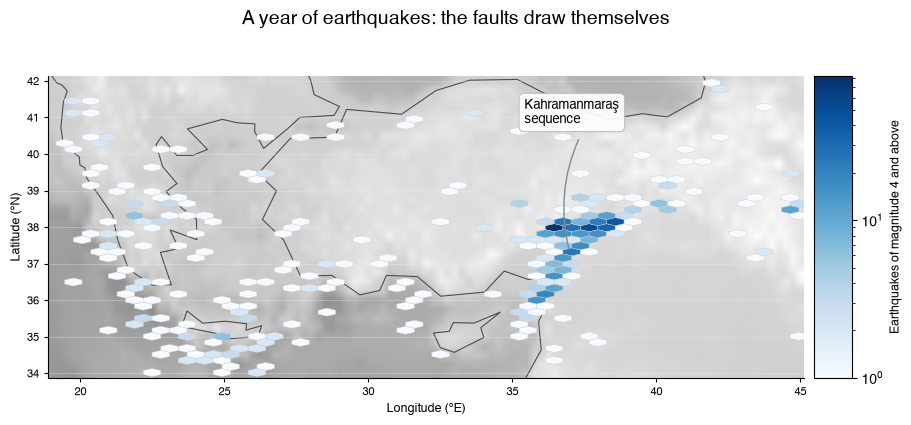

In [3]:
LATITUDE, LONGITUDE, DEPTH, MAGNITUDE = 1, 2, 3, 4
latitude = np.array([event[LATITUDE] for event in EVENTS])
longitude = np.array([event[LONGITUDE] for event in EVENTS])
magnitude = np.array([event[MAGNITUDE] for event in EVENTS])

# the largest event of the year, and the one that followed it nine hours later
main = int(magnitude.argmax())
second = int(np.where(magnitude < magnitude[main], magnitude, 0).argmax())

# the relief as a faded grey picture; a picture's first row is its top, so
# the grid's rows go north first, and each sample is a quarter-degree cell
HALF_STEP = 0.125
relief_image = ImageChart(
    {
        "image": np.array(RELIEF["z"])[::-1],
        "extent": (
            RELIEF["lon"][0] - HALF_STEP,
            RELIEF["lon"][-1] + HALF_STEP,
            RELIEF["lat"][0] - HALF_STEP,
            RELIEF["lat"][-1] + HALF_STEP,
        ),
    },
    style={"plot_image_alpha": 0.45, "plot_image_interpolation": "bilinear"},
)

density = HexbinChart(
    {"x": longitude.tolist(), "y": latitude.tolist()},
    gridsize=42,
    # counts run from 1 to several hundred, so the colour scale is logarithmic
    norm=NORMALIZE.LOG,
    mincnt=1,
    # a hairline edge keeps the single-event cells visible on white
    style={"plot_hexbin_edge_width": 0.3, "plot_hexbin_edge_color": "#d0d0d0"},
    show_colorbars=True,
    colorbar={"label": "Earthquakes of magnitude 4 and above"},
    texts={
        "text": "Kahramanmaraş\nsequence",
        "x": 0.63,
        "y": 0.88,
        "coords": "axes",
        "target": (longitude[main], latitude[main]),
    },
)

# the coastline alone, so the relief shows through the land, drawn darker
# than the theme grey so it reads on the relief
coastline = BasemapChart(
    BASEMAP_FEATURE.COASTLINE,
    style={"plot_basemap_coastline_color": "#4d4d4d", "plot_basemap_coastline_width": 0.8},
)

# the image and the coastline sit below the hexagons whatever the order of
# the figures; between the two, the one listed first draws first
epicentre_figure = Panel(
    [relief_image, coastline, density],
    title="A year of earthquakes: the faults draw themselves",
    xlabel="Longitude (°E)",
    ylabel_left="Latitude (°N)",
    # a degree of longitude narrowed by the cosine of the mid latitude
    aspect_ratio=ASPECT_RATIO.GEOGRAPHIC,
    figsize=(9.0, 4.2),
)
epicentre_figure.show()

The bright cells trace lines rather than filling the box, and the lines are the faults. One dense band runs northeast to southwest at about 37 degrees east, where 560 of the year's 831 events fall within 200 km of a single epicentre: that is the Kahramanmaraş sequence, and the rest of this page is largely about it. A second, fainter band curves down the west of the region, from Albania through western Greece and along the arc south of Crete, where the African plate dives beneath the Aegean. The two together hold 90% of the year's earthquakes, and the ground between them is nearly blank.

### What does the ground under them look like?

Epicentres are points on a surface, and the surface is what a reader needs in order to place them. A [contour chart](../../how-to-guides/charts/contourchart/) draws a gridded field as filled bands between its level lines, so the ETOPO relief becomes the shape of the region: the Aegean basin, the Anatolian plateau, and the mountain front between them. The grid goes in as `z` with its `lat` and `lon` axes, `filled` shades the bands, and `levels` sets how many are drawn. Elevation is signed, so the colormap is a diverging one and `vmin` and `vmax` are set symmetrically about zero: sea level lands on its pale midpoint, and the coastline appears without a coastline dataset. The two mainshocks are `texts` notes anchored to their own coordinates.

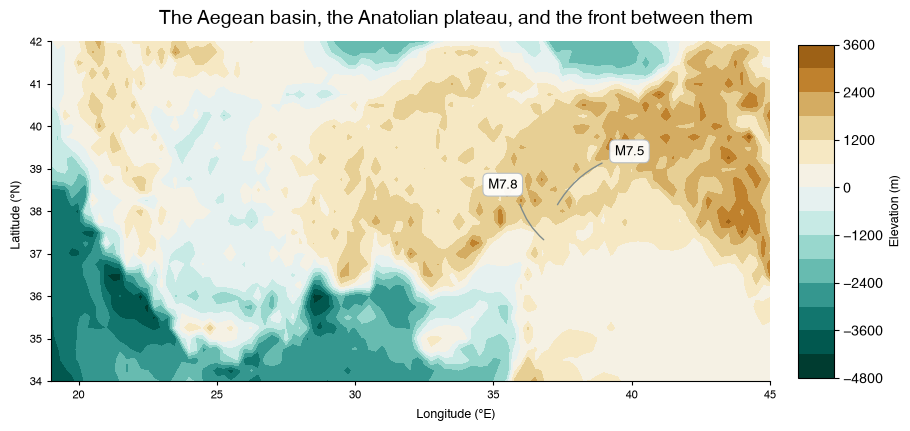

In [4]:
relief_figure = ContourChart(
    {"x": RELIEF["lon"], "y": RELIEF["lat"], "z": RELIEF["z"]},
    title="The Aegean basin, the Anatolian plateau, and the front between them",
    xlabel="Longitude (°E)",
    ylabel="Latitude (°N)",
    filled=True,
    levels=14,
    # a diverging colormap with the range symmetric about zero, so sea
    # level falls on its pale midpoint and the coastline draws itself
    style={"plot_contour_cmap": "BrBG_r"},
    vmin=-4500,
    vmax=4500,
    show_colorbars=True,
    colorbar={"label": "Elevation (m)"},
    texts=[
        {
            "text": f"M{magnitude[index]:.1f}",
            "x": longitude[index] + offset,
            "y": latitude[index] + 1.4,
            "target": (longitude[index], latitude[index]),
        }
        for index, offset in [(main, -2.2), (second, 2.2)]
    ],
    figsize=(9.0, 4.2),
)
relief_figure.show()

Sea level sits at the midpoint of the colour scale, so the coastline is the band where the shading changes sign and the Aegean reads as a shallow sea between two land masses. The two mainshocks sit on the mountain front that runs northeast from the corner of the Mediterranean, where the colour changes fastest. The relief is steep there for the same reason the earthquakes are there: the Arabian plate is pushing north into Anatolia, so the crust is both breaking and rising. The deepest cells, in the lower left, are the Hellenic trench at more than 4,000 m below sea level, which is the surface expression of the arc the hexbin figure picked out.

## The sequence

### How are the magnitudes distributed?

Earthquake sizes follow the Gutenberg-Richter law: the number of events of magnitude M or greater falls by a constant factor for every unit of magnitude, so a plot of the cumulative count against magnitude is a straight line on a logarithmic count axis. The slope of that line is the b-value, which is close to 1 for most of the world and is the number a seismicity report quotes. A [line chart](../../how-to-guides/charts/linechart/) with `scaley=SCALE.LOG` draws it, and a second series carries the fitted line so the eye can judge the fit rather than trust it.

The line bends away from the data at the left because a catalogue misses small events far from stations. The magnitude where that begins is the completeness magnitude, taken here as 4.5 and marked with `vlines`; the b-value is estimated from the events above it with the Aki maximum-likelihood formula, which needs only their mean magnitude.

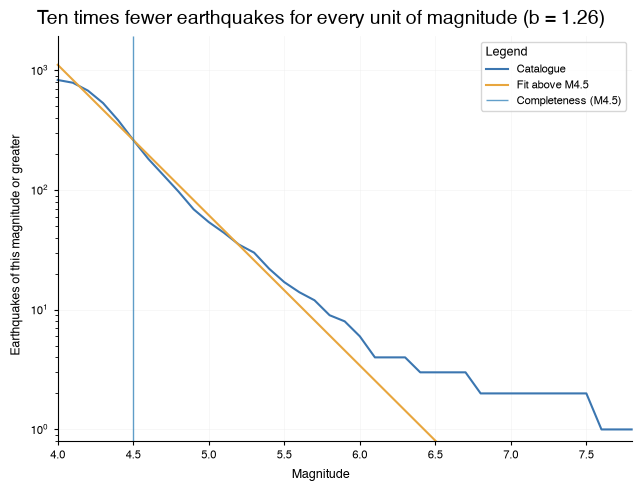

In [5]:
MC = 4.5  # the magnitude above which the catalogue is complete

steps = np.round(np.arange(4.0, magnitude.max() + 0.1, 0.1), 1)
cumulative = [int((magnitude >= step - 1e-9).sum()) for step in steps]

# Aki's maximum-likelihood b-value, from the mean magnitude above MC
complete = magnitude[magnitude >= MC]
b_value = 1 / (math.log(10) * (complete.mean() - (MC - 0.05)))
a_value = math.log10(len(complete)) + b_value * MC

gutenberg_figure = LineChart(
    [
        [{"x": float(step), "y": count} for step, count in zip(steps, cumulative)],
        [
            {"x": float(step), "y": 10 ** (a_value - b_value * step)}
            for step in steps
        ],
    ],
    title=f"Ten times fewer earthquakes for every unit of magnitude (b = {b_value:.2f})",
    xlabel="Magnitude",
    ylabel="Earthquakes of this magnitude or greater",
    subtitle=["Catalogue", f"Fit above M{MC}"],
    # the counts fall by three orders of magnitude across the axis
    scaley=SCALE.LOG,
    # the fit runs on below one event a year; the axis stops where the data does
    ymin=0.8,
    vlines={"x": MC, "label": f"Completeness (M{MC})"},
    show_legend=True,
    show_grid=SHOW_GRID.BOTH,
    figsize=FIG_SIZE.FULL_MEDIUM,
)
gutenberg_figure.show()

Below the completeness line the observed curve falls away from the fit, which is the catalogue missing small events rather than the Earth producing fewer of them. Above it the two follow each other from magnitude 4.5 to about 5.5, and then part again in the other direction: the catalogue counts six events of magnitude 6 and above where the fit predicts 3.4, and two above magnitude 7 where the fit predicts 0.2. The fitted b-value of 1.26 sits a little above the global average of 1, which means the region produces proportionally more small earthquakes than large ones. The excess at the top of the scale is the other half of the same reading: a rate of 0.2 magnitude 7 events a year is one every five years, and 2023 had two, so this was not an average year.

### How fast did the aftershocks die away?

Aftershock rates decay as one over the time since the mainshock, which is Omori's law, and the decay spans three orders of magnitude in both time and rate. Both axes therefore need a logarithmic scale, set with `scalex` and `scaley` on the same [line chart](../../how-to-guides/charts/linechart/), where the power law is again a straight line. The rate is counted in bins that widen with time, because a fixed daily bin would hold hundreds of events on the first day and none at all after a month.

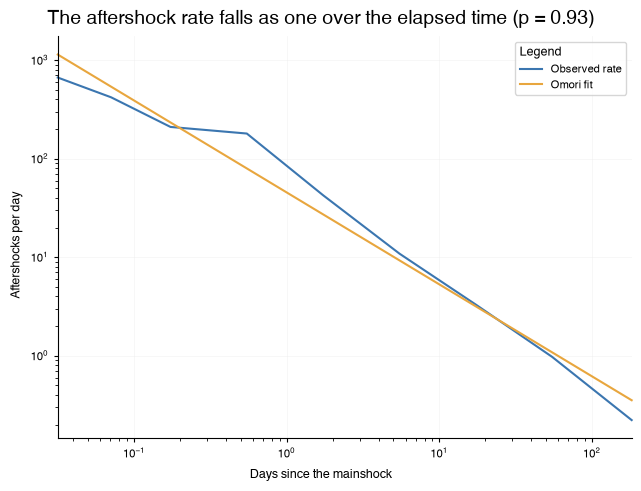

In [6]:
HOURS = 0
hours = np.array([event[HOURS] for event in EVENTS])

# everything after the mainshock within 200 km of it
km_per_degree_east = 111.2 * math.cos(math.radians(latitude[main]))
distance = np.hypot(
    (latitude - latitude[main]) * 111.2,
    (longitude - longitude[main]) * km_per_degree_east,
)
after = (hours > hours[main]) & (distance <= 200)
elapsed = (hours[after] - hours[main]) / 24

# bins that widen with time, so each one holds enough events to count
edges = np.array([0.02, 0.05, 0.1, 0.3, 1, 3, 10, 30, 100, 330])
counts, _ = np.histogram(elapsed, bins=edges)
centres = np.sqrt(edges[:-1] * edges[1:])
rate = counts / np.diff(edges)

observed = counts > 0
slope, intercept = np.polyfit(
    np.log10(centres[observed]), np.log10(rate[observed]), 1
)

omori_figure = LineChart(
    [
        [
            {"x": float(day), "y": float(value)}
            for day, value in zip(centres[observed], rate[observed])
        ],
        [
            {"x": float(day), "y": 10 ** (intercept + slope * math.log10(day))}
            for day in centres
        ],
    ],
    title=f"The aftershock rate falls as one over the elapsed time (p = {-slope:.2f})",
    xlabel="Days since the mainshock",
    ylabel="Aftershocks per day",
    subtitle=["Observed rate", "Omori fit"],
    scalex=SCALE.LOG,
    scaley=SCALE.LOG,
    show_legend=True,
    show_grid=SHOW_GRID.BOTH,
    figsize=FIG_SIZE.FULL_MEDIUM,
)
omori_figure.show()

The first day carried 214 aftershocks of magnitude 4 and above, and by the end of the year the rate is under one a week. The points lie on the fitted line from a few hours out to the tenth month, so one power law describes the whole decay. The fitted exponent of 0.93 is within the usual range of 0.9 to 1.4, and it has a practical reading: the rate roughly halves every time the elapsed time doubles, so the hazard a week after the mainshock is about a seventh of the hazard on the first day. The first two points sit below the line rather than on it, which is a known limitation of catalogues rather than a feature of the Earth: in the hours after a great earthquake the ground never stops shaking, and smaller events are lost in the noise before they can be measured.

### When did they arrive?

A power law gives the shape of the decay, and the calendar gives its size against the rest of the year. Daily counts over a year are 365 numbers with a strong local structure, which a [calendar heatmap](../../how-to-guides/charts/calendarheatmap/) lays out as a calendar, one cell per day coloured by its count. The mainshock day holds more than two hundred events and every ordinary day holds none or one, so `vmax` caps the colour scale well below the peak: the February cells saturate and the rest of the year keeps its contrast.

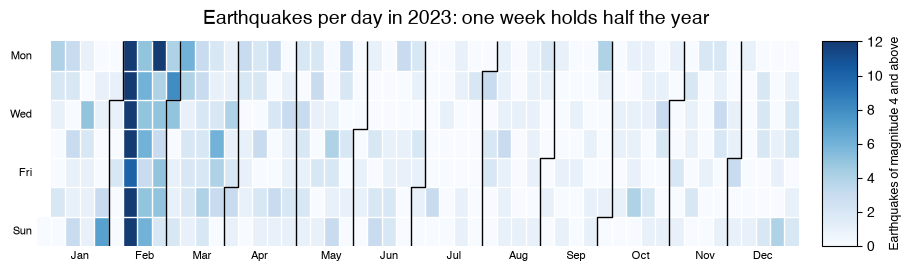

In [7]:
DAYS = [date(2023, 1, 1) + timedelta(days=offset) for offset in range(365)]
per_day = np.bincount((hours // 24).astype(int), minlength=365)[:365]

calendar_figure = CalendarHeatmap(
    {"date": DAYS, "value": per_day.tolist()},
    title="Earthquakes per day in 2023: one week holds half the year",
    figsize=(9.0, 2.6),
    aspect_ratio=ASPECT_RATIO.AUTO,
    # the mainshock day is an order of magnitude above any other
    vmax=12,
    show_colorbars=True,
    colorbar={"label": "Earthquakes of magnitude 4 and above"},
)
calendar_figure.show()

The year is almost empty apart from February, which is dark for its whole length and black in its first week. The single darkest cell is 6 February, with 224 events, and the week beginning there holds 47% of the year's earthquakes. The figure also shows what the Omori fit implies: the cells fade through March and April rather than stopping, because an aftershock sequence has no end, only a rate that falls below the rate of everything else.

### Which way did the rupture run?

A fault is a line, so its aftershocks spread along a direction rather than filling a circle, and the direction is the strike of the fault that broke. The azimuth from the mainshock to each aftershock is an angle, and angles belong on a circular axis: a [radial chart](../../how-to-guides/charts/radialchart/) with `mark=RADIAL_TYPE.HISTOGRAM` counts them into sectors and draws the rose diagram that structural geology has used for a century. The chart bins the raw angles itself, so each record carries one azimuth as `x`, and the default orientation already puts north at the top and runs clockwise, which is the compass convention.

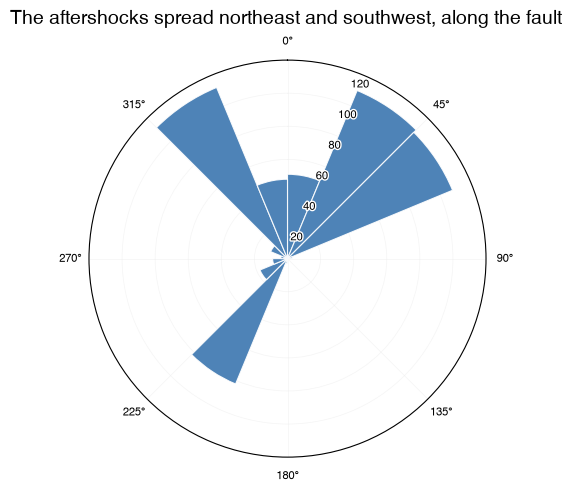

In [8]:
# the compass bearing from the mainshock to each aftershock
azimuth = np.degrees(
    np.arctan2(
        (longitude[after] - longitude[main]) * km_per_degree_east,
        (latitude[after] - latitude[main]) * 111.2,
    )
) % 360

rose_figure = RadialChart(
    [{"x": float(bearing)} for bearing in azimuth],
    mark=RADIAL_TYPE.HISTOGRAM,
    title="The aftershocks spread northeast and southwest, along the fault",
    # 16 sectors of 22.5 degrees, the usual resolution of a rose diagram
    num_bins=16,
    show_grid=SHOW_GRID.BOTH,
    figsize=FIG_SIZE.SQUARE,
)
rose_figure.show()

The rose has three lobes and an empty quarter. The pair pointing northeast and southwest are opposite bearings along one line, and that line is the strike of the East Anatolian Fault: an aftershock zone is the length of the rupture, so its shape is the fault drawn by its own earthquakes. Only four aftershocks fall in the whole quarter between east and south, which is the measure of how tightly the rest is aligned. The third lobe, between northwest and north, is the second rupture: the magnitude 7.5 event nine hours later broke a different fault 88 km almost due north of the first, and its aftershocks spread on either side of that bearing. A map of the same points would leave the reader to estimate the trends by eye.

## The instruments

### Which stations were watching?

Every number on this page comes from instruments, and the geometry of those instruments decides how well an earthquake can be located: an event inside a dense array is pinned down, one outside it is not. A [network chart](../../how-to-guides/charts/networkchart/) with `layout=NETWORK_LAYOUT.FIXED` draws each station at the position given in its own `x` and `y`, so the figure is the station map rather than a diagram of one. The layout works inside a unit square, so both axes take one scale factor and the region keeps its proportions. The region is three times as wide as it is tall, which packs the western stations into a corner, so a second panel repeats the exercise for the stations west of 30 degrees east alone and names every one of them. The edges are the baselines between stations closer than 250 km to each other, excluding the zero-length one where two operators share a single site, and node size counts the baselines each station has. Five operators are represented: the Albanian Seismological Network, GEOFON, the Aristotle University of Thessaloniki network, the Global Seismograph Network, and MedNet.

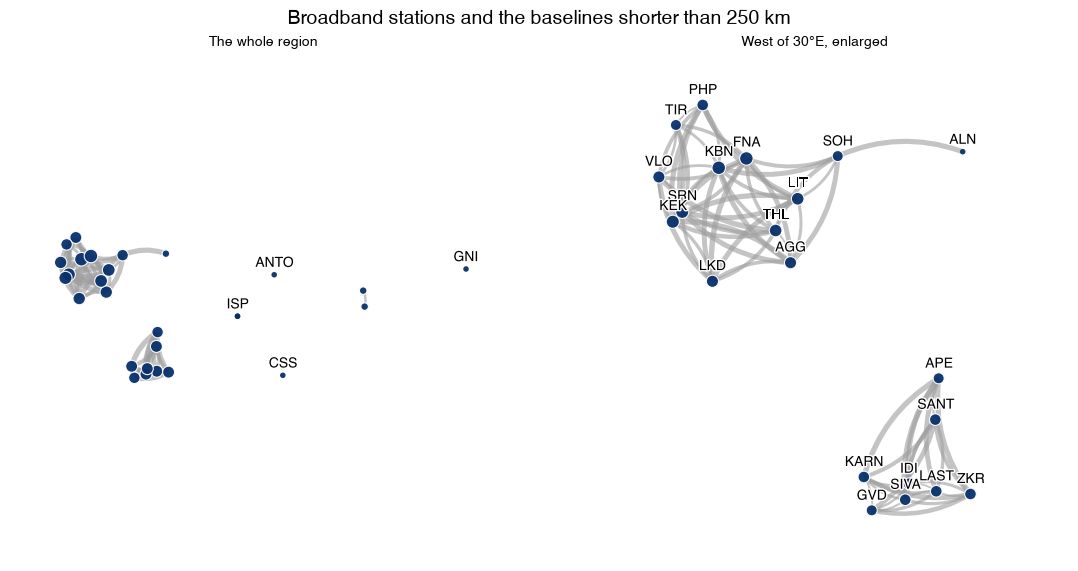

In [9]:
CODE, STATION_LAT, STATION_LON = 0, 1, 2
BASELINE_KM = 250
ZOOM_EAST = 30  # the meridian the enlarged panel stops at


def separation(one, other):
    """The distance between two stations in kilometres."""
    mean_latitude = math.radians((one[STATION_LAT] + other[STATION_LAT]) / 2)
    return math.hypot(
        (one[STATION_LAT] - other[STATION_LAT]) * 111.2,
        (one[STATION_LON] - other[STATION_LON]) * 111.2 * math.cos(mean_latitude),
    )


def station_map(group, subtitle, name_every):
    """A map of `group`, scaled into the unit square the fixed layout uses."""
    edges = [
        {"source": one[CODE], "target": other[CODE], "weight": separation(one, other)}
        for index, one in enumerate(group)
        for other in group[index + 1 :]
        # a zero-length baseline is two operators sharing one site, not a pair
        if 0 < separation(one, other) <= BASELINE_KM
    ]
    baselines = {station[CODE]: 0 for station in group}
    for edge in edges:
        baselines[edge["source"]] += 1
        baselines[edge["target"]] += 1

    # both axes take one scale factor, so the region keeps its proportions
    middle = math.radians(sum(s[STATION_LAT] for s in group) / len(group))
    east = {s[CODE]: s[STATION_LON] * 111.2 * math.cos(middle) for s in group}
    north = {s[CODE]: s[STATION_LAT] * 111.2 for s in group}
    span = max(
        max(east.values()) - min(east.values()),
        max(north.values()) - min(north.values()),
    )

    def unit(places, value):
        reach = max(places.values()) - min(places.values())
        return (value - min(places.values())) / span + (1 - reach / span) / 2

    return NetworkChart(
        {
            "nodes": [
                {
                    "id": station[CODE],
                    # the wide panel names only the stations with no baseline
                    "label": station[CODE].split(".")[1]
                    if name_every or not baselines[station[CODE]]
                    else "",
                    "x": unit(east, east[station[CODE]]),
                    "y": unit(north, north[station[CODE]]),
                    "size": 1 + baselines[station[CODE]],
                }
                for station in group
            ],
            "edges": edges,
        },
        layout=NETWORK_LAYOUT.FIXED,
        label_position=NETWORK_LABEL_POSITION.ABOVE,
        subtitle=subtitle,
        style={"plot_network_node_size_min": 16, "plot_network_node_size_max": 95},
    )


aegean = [station for station in STATIONS if station[STATION_LON] <= ZOOM_EAST]

Grid(
    [
        [
            station_map(STATIONS, "The whole region", name_every=False),
            station_map(aegean, f"West of {ZOOM_EAST}°E, enlarged", name_every=True),
        ]
    ],
    title=f"Broadband stations and the baselines shorter than {BASELINE_KM} km",
    figsize=(11.0, 5.6),
).show()

The array breaks into three linked groups and five stations standing alone, and the split runs from west to east. The enlarged panel holds two of the groups and 79 of the 80 baselines: thirteen stations across Albania and northern Greece, where the busiest carries eleven, and eight more ringing Crete and the southern Aegean. East of there the map empties out. A pair sits in eastern Türkiye, and the rest are singletons: Cyprus, Ankara, Garni in Armenia, and Isparta, where two operators run instruments at one site, so the figure draws them on top of each other and one label covers both. The 28 stations here are the globally shared broadband instruments alone, and the national networks that do the routine work in Türkiye and Greece are denser, so a location computed from them is better than this array by itself would give. Read against the first figure the geometry still matters, because the most active part of the region is where this array is thinnest.

## The report figure

A paper has room for one figure, not seven. The four that carry the argument (where the earthquakes are, how their sizes are distributed, how the aftershocks decayed, and which way the rupture ran) go into one panel with [Grid](../../how-to-guides/utility/grid/), which takes the figures already drawn above and redraws them into its cells. Nested lists are the layout, one inner list per row.

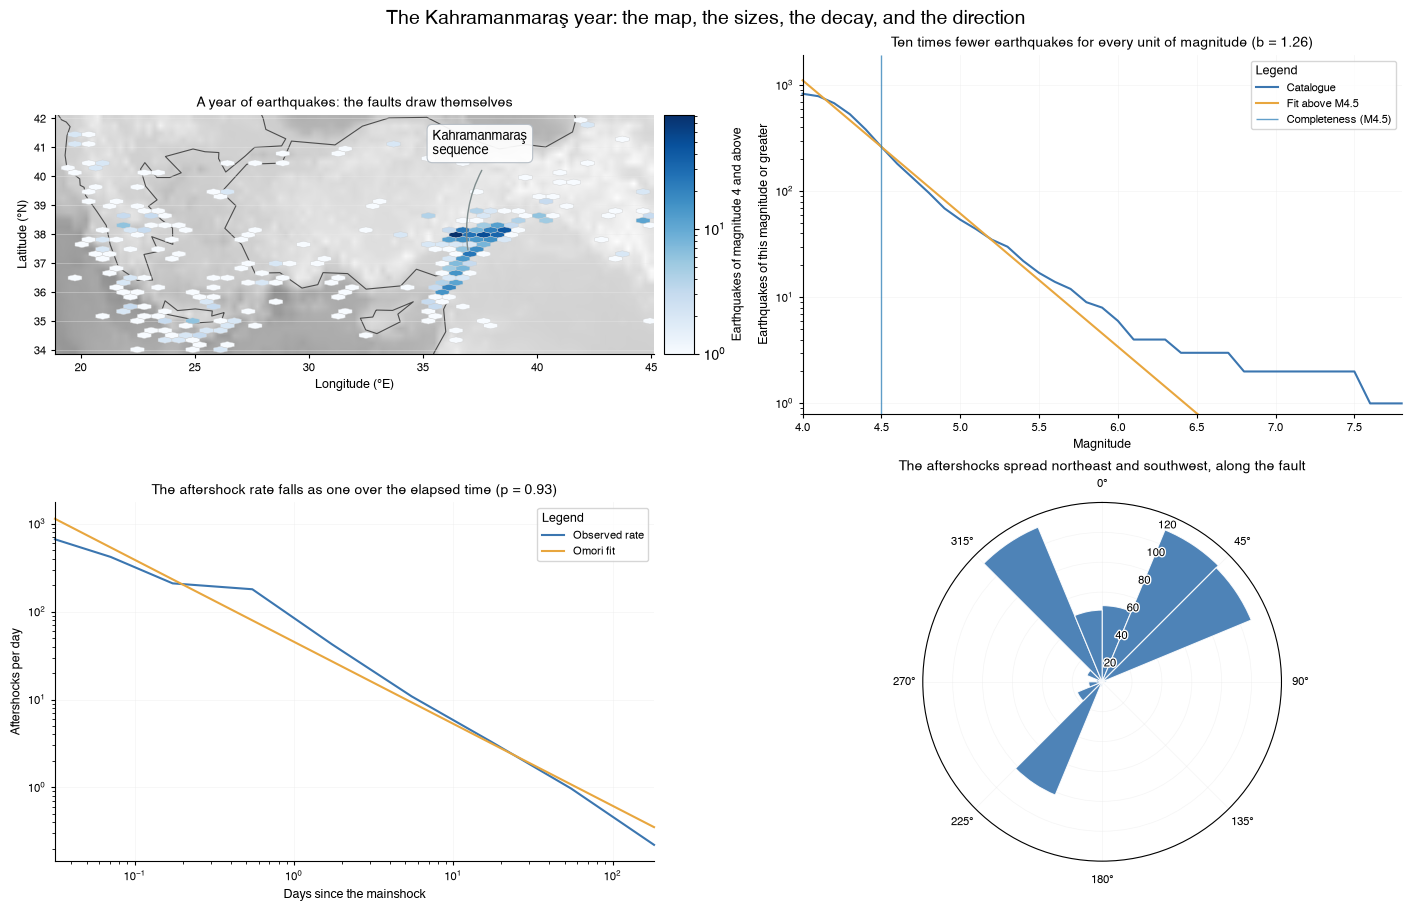

In [10]:
Grid(
    [
        [epicentre_figure, gutenberg_figure],
        [omori_figure, rose_figure],
    ],
    title="The Kahramanmaraş year: the map, the sizes, the decay, and the direction",
    figsize=(14.0, 9.0),
).show()

One number on this page is worth a caveat: 445 of the 831 events, more than half, carry a depth of exactly 10 km, which is the value the catalogue assigns when the depth is not resolved, so a figure of depth against anything would be drawing the convention rather than the Earth. This page therefore has no depth figure. Every other figure is one call to a chart function over a list of dicts, and every number in them comes from a few lines of numpy written out in the cell above it. To adapt any of them, open the guide it links to and read the parameter that does the job; the [annotations guide](../../how-to-guides/utility/annotations/) covers the reference lines and notes the figures share. The charts index lists them all: [Charts](../../how-to-guides/charts/).